**Explainable Medical (EM)-LLM:  External Validation & Cross-Institutional Generalization**    
**Presented by: Reza AI (2025–2026)**  
*E-mail: Reza.Saadatyar92@gmail.com* 

**Objective: External Validation and Cross-Institutional Generalization on eICU-CRD**

The objective of this notebook is to evaluate the fine-tuned medical LLM from Notebook 05 on an external clinical cohort derived from the eICU-CRD dataset. The notebook extracts a structured external validation cohort, formats eICU patient records into the same instruction style used during fine-tuning, runs deterministic inference with the saved LoRA adapter, and measures how well the model generalizes beyond the original MIMIC-based development setting.

This notebook does not perform additional model training. Instead, it focuses on external validation, domain-shift analysis, internal-versus-external performance comparison, drift alert generation, and final artifact integrity checks.

**Expected Main Outputs**  
The main outputs of this notebook include:

`external_eicu_cohort_07.csv`  
A structured external validation cohort extracted from eICU patient and vital-sign archives.

`external_eicu_eval_sample_07.csv`  
A model-ready external evaluation sample formatted for instruction-style inference.

`phase7_external_results.csv`  
Row-level external validation predictions, including ground-truth labels, parsed model predictions, correctness flags, probabilities, and trace metadata.

`phase7_external_metrics.json`  
A structured summary of external validation metrics.

`phase7_external_confusion_matrix.png`  
A confusion-matrix visualization for the eICU external validation results.

`phase7_external_metric_shift_vs_phase6.csv`  
A metric-shift table comparing external eICU performance against the internal Notebook 06 baseline.

`phase7_external_drift_alerts.csv`  
A drift-alert table highlighting clinically relevant external performance drops or distribution shifts.

`notebook_07_external_validation_audit.json`  
The final consolidated audit file for external validation, artifact traceability, internal-external comparison, and integrity checking.

**Preliminary Setup: Library Import, Environment Setup, and External Validation Utilities**

This setup prepares the external validation environment before extracting the eICU cohort or loading the fine-tuned model. It imports the required libraries, validates project directories, resolves the saved LoRA adapter from Notebook 05, checks the internal evaluation artifacts from Notebook 06, and registers shared utility functions for cohort extraction, label parsing, metric calculation, and audit export.

**Main Operations**  
◽ Import libraries for compressed file loading, data processing, model inference, metrics, plotting, and audit reporting  
◽ Validate the project base directory and create shared output and quality-control folders  
◽ Resolve the available eICU-CRD source directory from supported folder names  
◽ Load the Notebook 05 adapter manifest and validate the task variant  
◽ Verify that required Notebook 06 internal baseline artifacts are available  
◽ Initialize external validation constants, label mappings, device settings, and audit metadata  
◽ Register helper functions for JSON/CSV export, Phase 06 artifact loading, external result resolution, label parsing, and metric computation  

**Technical and Clinical Significance**  
This setup ensures that external validation is performed against the correct trained adapter and the correct internal benchmark. Validating Notebook 05 and Notebook 06 dependencies before inference prevents task mismatch, missing-baseline comparisons, and incomplete audit reporting.

**Expected Outcome**  
The notebook is ready for eICU external validation, with validated paths, adapter metadata, internal baseline artifacts, label definitions, and reusable evaluation utilities.

In [1]:
# =====================================================================
# Imported Libraries (Categorized)
# =====================================================================

# ---------------------------------------------------------
# 0) Standard Library & Project Path Management
# ---------------------------------------------------------
import os
import sys
import re
import json
from pathlib import Path

# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ---------------------------------------------------------
# 1) Data and Numerical
# ---------------------------------------------------------
import math
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 2) Visualisation
# ---------------------------------------------------------
import seaborn as sns
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 3) Machine Learning and Metrics
# ---------------------------------------------------------
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    auc,
)

# ---------------------------------------------------------
# 4) Deep Learning and PEFT
# ---------------------------------------------------------
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# ---------------------------------------------------------
# 5) Internal Project Utilities
# ---------------------------------------------------------
from src.utils.hardware_verification import verify_hardware

# ---------------------------------------------------------
# 6) Global Configurations
# ---------------------------------------------------------
# Academic Plot Style for Medical Reporting
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# ---------------------------------------------------------
# 7) Global Device Configuration for PyTorch
# ---------------------------------------------------------
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")

Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


In [2]:
# =====================================================================
# Environment Setup - Paths, Constants, and Dependency Validation
# =====================================================================

# ---------------------------------------------------------
# 0) Guard: Base Directory Validation
# ---------------------------------------------------------

if "BASE_DIR" not in globals():
    BASE_DIR = (
        Path.home()
        / "OneDrive - hull.ac.uk"
        / "Explainable Medical LLM Dataset"
        / "datasets"
    )

BASE_DIR = Path(BASE_DIR)

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"BASE_DIR not found: {BASE_DIR}\n"
        "Ensure OneDrive is synced and the dataset folder is accessible."
    )

# ---------------------------------------------------------
# 1) Directory Definitions
# ---------------------------------------------------------

QUALITY_DIR = BASE_DIR / "quality_reports"
OUTPUTS_DIR = BASE_DIR / "outputs"
ADAPTER_DIR = OUTPUTS_DIR / "medical_llm_adapters"

QUALITY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

eicu_dir_candidates = [
    BASE_DIR / "eicu_crd",
    BASE_DIR / "eicu",
    BASE_DIR / "eicu-crd",
]

EICU_DIR = next((p for p in eicu_dir_candidates if p.exists()), None)

if EICU_DIR is None:
    raise FileNotFoundError(
        "eICU directory not found. Checked:\n"
        + "\n".join(f"  {p}" for p in eicu_dir_candidates)
    )

# ---------------------------------------------------------
# 2) Notebook 05 Adapter Contract
# ---------------------------------------------------------

ADAPTER_PATH = ADAPTER_DIR / "v1"
ADAPTER_MANIFEST_PATH = ADAPTER_PATH / "adapter_manifest_05.json"

if not ADAPTER_PATH.exists():
    raise FileNotFoundError(
        "Notebook 05 adapter directory not found:\n"
        f"  {ADAPTER_PATH}\n"
        "Run Notebook 05 Step 7 before Notebook 07."
    )

if not ADAPTER_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Adapter manifest not found:\n"
        f"  {ADAPTER_MANIFEST_PATH}\n"
        "Notebook 07 requires adapter_manifest_05.json to prevent task mismatch."
    )

with open(ADAPTER_MANIFEST_PATH, "r", encoding="utf-8") as f:
    adapter_manifest = json.load(f)

ADAPTER_TASK_VARIANT = str(adapter_manifest.get("task_variant", "")).strip()
BASE_MODEL_ID = str(adapter_manifest.get("model_id", "BioMistral/BioMistral-7B")).strip()
ADAPTER_TRAINING_RESPONSE_MODE = str(
    adapter_manifest.get("training_response_mode", "classification_only")
).strip()

if ADAPTER_TASK_VARIANT not in {"early_ed", "retrospective"}:
    raise ValueError(
        "Unsupported or missing task_variant in adapter_manifest_05.json. "
        f"Expected 'early_ed' or 'retrospective', got: {ADAPTER_TASK_VARIANT!r}"
    )

if ADAPTER_TRAINING_RESPONSE_MODE != "classification_only":
    print(
        "Warning: adapter training_response_mode is not classification_only. "
        f"Found: {ADAPTER_TRAINING_RESPONSE_MODE}"
    )

# ---------------------------------------------------------
# 3) Notebook 06 Internal Baseline Dependencies
# ---------------------------------------------------------

PHASE6_AUDIT_PATH = QUALITY_DIR / "pipeline_audit_unified_06.json"
PHASE6_EVAL_AUDIT_PATH = QUALITY_DIR / "phase6_evaluation_audit.json"
PHASE6_RESULTS_PATH = QUALITY_DIR / "phase6_batch_results.csv"
PHASE6_RISK_PATH = QUALITY_DIR / "phase6_clinical_risk_audit.csv"
PHASE6_CLASSWISE_PATH = QUALITY_DIR / "phase6_classwise_metrics.csv"
PHASE6_MODEL_BOARD_PATH = QUALITY_DIR / "xai_model_comparison_metrics.csv"

required_phase6_paths = {
    "pipeline_audit_unified_06": PHASE6_AUDIT_PATH,
    "phase6_evaluation_audit": PHASE6_EVAL_AUDIT_PATH,
    "phase6_batch_results": PHASE6_RESULTS_PATH,
    "phase6_clinical_risk_audit": PHASE6_RISK_PATH,
    "phase6_classwise_metrics": PHASE6_CLASSWISE_PATH,
    "xai_model_comparison_metrics": PHASE6_MODEL_BOARD_PATH,
}

missing_phase6 = {
    name: path for name, path in required_phase6_paths.items()
    if not path.exists()
}

if missing_phase6:
    raise FileNotFoundError(
        "Required Notebook 06 baseline artifacts are missing:\n"
        + "\n".join(f"  {name}: {path}" for name, path in missing_phase6.items())
        + "\nRun Notebook 06 with the updated code before Notebook 07."
    )

# ---------------------------------------------------------
# 3.1) Threshold / Probability Contract from Notebook 06 or Notebook 05
# ---------------------------------------------------------

DEFAULT_EXPIRED_THRESHOLD = 0.50
BEST_EXPIRED_THRESHOLD = DEFAULT_EXPIRED_THRESHOLD
THRESHOLD_SOURCE = "default_0.50"

phase6_board = None

try:
    phase6_board = pd.read_csv(PHASE6_MODEL_BOARD_PATH)

    if (
        len(phase6_board) > 0
        and "best_expired_threshold" in phase6_board.columns
        and pd.notna(phase6_board["best_expired_threshold"].iloc[0])
    ):
        BEST_EXPIRED_THRESHOLD = float(phase6_board["best_expired_threshold"].iloc[0])
        THRESHOLD_SOURCE = str(PHASE6_MODEL_BOARD_PATH)

except Exception as exc:
    print(f"Warning: failed to read Notebook 06 model board threshold: {type(exc).__name__}")

if THRESHOLD_SOURCE == "default_0.50":
    notebook05_metrics_path = QUALITY_DIR / "finetune_eval_metrics_05.json"

    if notebook05_metrics_path.exists():
        try:
            with open(notebook05_metrics_path, "r", encoding="utf-8") as f:
                notebook05_metrics = json.load(f)

            if notebook05_metrics.get("best_threshold_EXPIRED") is not None:
                BEST_EXPIRED_THRESHOLD = float(notebook05_metrics["best_threshold_EXPIRED"])
                THRESHOLD_SOURCE = str(notebook05_metrics_path)

        except Exception as exc:
            print(f"Warning: failed to read Notebook 05 threshold: {type(exc).__name__}")

# ---------------------------------------------------------
# 4) External Evaluation Constants
# ---------------------------------------------------------

EXTERNAL_EVAL_SAMPLE_SIZE = 10000 # None
EXTERNAL_EVAL_RANDOM_SEED = 42
VITALS_READ_ROWS = None   # 100000

VALID_LABELS = ["SURVIVED", "EXPIRED"]
LABEL_TO_ID = {"SURVIVED": 0, "EXPIRED": 1}
ID_TO_LABEL = {0: "SURVIVED", 1: "EXPIRED"}

POSITIVE_LABEL = "EXPIRED"
NEGATIVE_LABEL = "SURVIVED"
POSITIVE_CLASS_ID = LABEL_TO_ID[POSITIVE_LABEL]

INFER_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------
# 5) Audit Dictionary Initialization
# ---------------------------------------------------------

external_eval_audit: dict = {
    "notebook": "07_external_validation_eicu",
    "base_dir": str(BASE_DIR),
    "eicu_dir": str(EICU_DIR),
    "quality_dir": str(QUALITY_DIR),
    "outputs_dir": str(OUTPUTS_DIR),
    "base_model_id": BASE_MODEL_ID,
    "adapter_path": str(ADAPTER_PATH),
    "adapter_manifest_path": str(ADAPTER_MANIFEST_PATH),
    "adapter_task_variant": ADAPTER_TASK_VARIANT,
    "adapter_training_response_mode": ADAPTER_TRAINING_RESPONSE_MODE,
    "phase6_dependencies": {
        name: str(path) for name, path in required_phase6_paths.items()
    },
    "external_eval_sample_size": EXTERNAL_EVAL_SAMPLE_SIZE,
    "external_eval_random_seed": EXTERNAL_EVAL_RANDOM_SEED,
    "vitals_read_rows": VITALS_READ_ROWS,
    "infer_device": INFER_DEVICE,
    "positive_label": POSITIVE_LABEL,
    "positive_class_id": POSITIVE_CLASS_ID,
    "best_expired_threshold": BEST_EXPIRED_THRESHOLD,
    "threshold_source": THRESHOLD_SOURCE,
    "prediction_contract": (
        "Use expired_probability >= BEST_EXPIRED_THRESHOLD as the primary external "
        "prediction rule. Generation text is retained for audit only."
    ),
}

# ---------------------------------------------------------
# 6) Confirmation
# ---------------------------------------------------------

print("Notebook 07 environment configured.")
print(f"BASE_DIR                     : {BASE_DIR}")
print(f"EICU_DIR                     : {EICU_DIR}")
print(f"QUALITY_DIR                  : {QUALITY_DIR}")
print(f"OUTPUTS_DIR                  : {OUTPUTS_DIR}")
print(f"BASE_MODEL_ID                : {BASE_MODEL_ID}")
print(f"ADAPTER_PATH                 : {ADAPTER_PATH}")
print(f"ADAPTER_TASK_VARIANT         : {ADAPTER_TASK_VARIANT}")
print(f"ADAPTER_RESPONSE_MODE        : {ADAPTER_TRAINING_RESPONSE_MODE}")
print(f"BEST_EXPIRED_THRESHOLD       : {BEST_EXPIRED_THRESHOLD}")
print(f"THRESHOLD_SOURCE             : {THRESHOLD_SOURCE}")
print(f"Inference device             : {INFER_DEVICE.upper()}")
print(f"External sample size         : {EXTERNAL_EVAL_SAMPLE_SIZE}")
print(f"Vitals row limit             : {VITALS_READ_ROWS}")
print("Notebook 06 dependencies verified.")


Notebook 07 environment configured.
BASE_DIR                     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
EICU_DIR                     : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\eicu_crd
QUALITY_DIR                  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
OUTPUTS_DIR                  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs
BASE_MODEL_ID                : BioMistral/BioMistral-7B
ADAPTER_PATH                 : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1
ADAPTER_TASK_VARIANT         : retrospective
ADAPTER_RESPONSE_MODE        : classification_only
BEST_EXPIRED_THRESHOLD       : 0.46
THRESHOLD_SOURCE             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xai_model_comparison_metrics.csv
In

In [3]:
# =====================================================================
# Utility Functions - Core Helpers for External eICU Validation
# =====================================================================

# ---------------------------------------------------------
# 0) JSON / CSV Persistence Helpers
# ---------------------------------------------------------

def save_json(payload: dict, path: Path) -> None:
    """Persist a JSON payload with stable UTF-8 formatting."""
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=str)

    print(f"Saved JSON: {path}")


def save_dataframe(df: pd.DataFrame, path: Path, label: str = "CSV") -> None:
    """Persist a DataFrame and fail early if the object is not valid."""
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{label} must be a pandas DataFrame, got {type(df)}")

    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

    print(f"Saved {label}: {path}")


def load_json_required(path: Path, label: str) -> dict:
    """Load a required JSON file with a clear error message."""
    if not path.exists():
        raise FileNotFoundError(f"Required {label} JSON not found: {path}")

    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    if not isinstance(payload, dict):
        raise TypeError(f"{label} must contain a JSON object: {path}")

    return payload


def load_csv_required(path: Path, label: str) -> pd.DataFrame:
    """Load a required CSV file and reject empty artifacts."""
    if not path.exists():
        raise FileNotFoundError(f"Required {label} CSV not found: {path}")

    df = pd.read_csv(path)

    if len(df) == 0:
        raise RuntimeError(f"Required {label} CSV is empty: {path}")

    return df


# ---------------------------------------------------------
# 1) Phase 06 Baseline Loader
# ---------------------------------------------------------

def load_phase6_baseline_artifacts() -> dict:
    """
    Load the internal MIMIC test baseline artifacts produced by Notebook 06.
    """
    phase6 = {
        "pipeline_audit": load_json_required(
            PHASE6_AUDIT_PATH,
            "Notebook 06 unified pipeline audit",
        ),
        "evaluation_audit": load_json_required(
            PHASE6_EVAL_AUDIT_PATH,
            "Notebook 06 evaluation audit",
        ),
        "batch_results": load_csv_required(
            PHASE6_RESULTS_PATH,
            "Notebook 06 batch results",
        ),
        "risk_audit": load_csv_required(
            PHASE6_RISK_PATH,
            "Notebook 06 clinical risk audit",
        ),
        "classwise_metrics": load_csv_required(
            PHASE6_CLASSWISE_PATH,
            "Notebook 06 class-wise metrics",
        ),
        "model_board": load_csv_required(
            PHASE6_MODEL_BOARD_PATH,
            "Notebook 06 model comparison board",
        ),
    }

    return phase6


# ---------------------------------------------------------
# 2) External Result Resolver
# ---------------------------------------------------------

def resolve_external_results(step_label: str = "") -> tuple[pd.DataFrame, str]:
    """
    Resolve the active Notebook 07 external prediction table.
    """
    priority_vars = [
        "external_results_df",
        "df_external_results",
        "df_results_external",
        "eicu_results_df",
        "df_ext",
    ]

    for var_name in priority_vars:
        obj = globals().get(var_name)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            return obj.copy(), var_name

    candidate_paths = [
        QUALITY_DIR / "phase7_external_results.csv",
        QUALITY_DIR / "phase8_external_results.csv",
    ]

    for path in candidate_paths:
        if path.exists():
            df = pd.read_csv(path)
            if len(df) > 0:
                return df, str(path)

    raise RuntimeError(
        f"[{step_label}] No external result table found. "
        "Run the eICU inference step first."
    )


# ---------------------------------------------------------
# 3) Label Parsing, Prompt Formatting, and Probability Helpers
# ---------------------------------------------------------

def parse_label(text: str) -> str:
    """
    Parse model/reference text into the project mortality label space.

    Returns:
      SURVIVED, EXPIRED, AMBIGUOUS, or UNKNOWN.
    """
    if not isinstance(text, str) or not text.strip():
        return "UNKNOWN"

    upper = str(text).upper()

    explicit_patterns = [
        r"\bOUTCOME\s*:\s*(SURVIVED|EXPIRED)\b",
        r"\bPREDICTED\s+OUTCOME\s*:\s*(SURVIVED|EXPIRED)\b",
        r"\bFINAL\s+OUTCOME\s*:\s*(SURVIVED|EXPIRED)\b",
        r"\bANSWER\s*:\s*(SURVIVED|EXPIRED)\b",
        r"^\s*(SURVIVED|EXPIRED)\s*$",
    ]

    explicit_hits = []

    for pattern in explicit_patterns:
        explicit_hits.extend(re.findall(pattern, upper))

    explicit_hits = [x for x in explicit_hits if x in VALID_LABELS]

    if len(set(explicit_hits)) == 1:
        return explicit_hits[-1]

    if len(set(explicit_hits)) > 1:
        return "AMBIGUOUS"

    survived_present = bool(re.search(r"\bSURVIVED\b|\bSURVIVE\b", upper))
    expired_present = bool(re.search(r"\bEXPIRED\b|\bDECEASED\b|\bDIED\b|\bDEATH\b", upper))

    if survived_present and expired_present:
        return "AMBIGUOUS"
    if expired_present:
        return "EXPIRED"
    if survived_present:
        return "SURVIVED"

    return "UNKNOWN"


def map_eicu_outcome(value: str) -> str:
    """Normalize eICU discharge status to the project label space."""
    s = str(value).strip().lower()

    expired_values = {
        "expired",
        "deceased",
        "death",
        "died",
        "dead",
        "mortality",
    }

    survived_values = {
        "alive",
        "survived",
        "survive",
        "discharged",
        "home",
        "transfer",
        "other",
    }

    if s in expired_values:
        return "EXPIRED"

    if s in survived_values:
        return "SURVIVED"

    if "expire" in s or "death" in s or "deceased" in s or "died" in s:
        return "EXPIRED"

    if "alive" in s or "surviv" in s or "discharg" in s:
        return "SURVIVED"

    return "UNKNOWN"


def labels_to_numeric(series: pd.Series) -> pd.Series:
    """Convert SURVIVED/EXPIRED labels to numeric ids used by Notebook 06."""
    return series.map(LABEL_TO_ID)


def mortality_classification_instruction() -> str:
    return (
        "Predict the hospital mortality outcome using only the available emergency "
        "department or ICU presentation data. Return exactly one label: SURVIVED or EXPIRED."
    )


def build_classification_prompt(input_text: str) -> str:
    """
    Build the same classification-only prompt contract used by Notebook 05/06.
    """
    return (
        f"### Instruction:\n"
        f"{mortality_classification_instruction()}\n\n"
        f"### Input:\n"
        f"{str(input_text).strip()}\n\n"
        f"### Response:\n"
    )


def extract_generated_response(raw_prediction: str, prompt: str = "") -> str:
    """Extract only the generated response segment from a decoded model output."""
    raw_prediction = str(raw_prediction)

    if prompt and raw_prediction.startswith(prompt):
        return raw_prediction[len(prompt):].strip()

    if "### Response:" in raw_prediction:
        return raw_prediction.split("### Response:", 1)[1].strip()

    return raw_prediction.strip()


def _active_model_device():
    if "model" not in globals():
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _label_continuation_for_prompt(prompt: str, label: str) -> str:
    """
    Match label continuation to the classification-only response format.
    """
    label = str(label).strip().upper()

    if label not in VALID_LABELS:
        raise ValueError(f"Invalid label continuation: {label}")

    if str(prompt).endswith("\n") or str(prompt).endswith(" "):
        return label

    return " " + label


def continuation_log_likelihood(
    prompt: str,
    continuation: str,
    *,
    normalize_by_tokens: bool = True,
) -> tuple[float, float, int]:
    """
    Compute continuation log-likelihood under the active model.
    Returns total LL, mean LL, and token count.
    """
    if "model" not in globals() or "tokenizer" not in globals():
        raise RuntimeError("Model/tokenizer must be loaded before probability scoring.")

    model.eval()
    device = _active_model_device()

    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    ).input_ids.to(device)

    full_ids = tokenizer(
        prompt + continuation,
        return_tensors="pt",
        add_special_tokens=False,
    ).input_ids.to(device)

    continuation_start = prompt_ids.shape[1]

    if full_ids.shape[1] <= continuation_start:
        return float("-inf"), float("-inf"), 0

    with torch.no_grad():
        outputs = model(full_ids)
        logits = outputs.logits

    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    target_ids = full_ids[:, 1:]

    total_ll = 0.0
    token_count = 0

    for pos in range(continuation_start - 1, full_ids.shape[1] - 1):
        token_id = target_ids[0, pos]
        total_ll += float(log_probs[0, pos, token_id].detach().cpu())
        token_count += 1

    if token_count == 0:
        return float("-inf"), float("-inf"), 0

    mean_ll = total_ll / token_count

    return total_ll, mean_ll, token_count


def compute_label_probabilities(prompt: str, normalize_by_tokens: bool = True) -> dict:
    """
    Estimate EXPIRED/SURVIVED probabilities from continuation likelihoods.
    EXPIRED is the positive class.
    """
    rows = {}

    for label in VALID_LABELS:
        continuation = _label_continuation_for_prompt(prompt, label)
        total_ll, mean_ll, token_count = continuation_log_likelihood(
            prompt,
            continuation,
            normalize_by_tokens=normalize_by_tokens,
        )

        score = mean_ll if normalize_by_tokens else total_ll

        rows[label] = {
            "total_log_likelihood": total_ll,
            "mean_log_likelihood": mean_ll,
            "token_count": token_count,
            "score": score,
        }

    max_score = max(v["score"] for v in rows.values())

    exp_scores = {
        label: math.exp(v["score"] - max_score) if math.isfinite(v["score"]) else 0.0
        for label, v in rows.items()
    }

    denom = sum(exp_scores.values())

    if denom <= 0:
        survived_probability = 0.5
        expired_probability = 0.5
    else:
        survived_probability = exp_scores["SURVIVED"] / denom
        expired_probability = exp_scores["EXPIRED"] / denom

    return {
        "survived_log_likelihood": rows["SURVIVED"]["total_log_likelihood"],
        "expired_log_likelihood": rows["EXPIRED"]["total_log_likelihood"],
        "survived_mean_log_likelihood": rows["SURVIVED"]["mean_log_likelihood"],
        "expired_mean_log_likelihood": rows["EXPIRED"]["mean_log_likelihood"],
        "survived_token_count": rows["SURVIVED"]["token_count"],
        "expired_token_count": rows["EXPIRED"]["token_count"],
        "survived_probability": survived_probability,
        "expired_probability": expired_probability,
        "score_normalized_by_tokens": bool(normalize_by_tokens),
    }


def threshold_label_from_probability(
    expired_probability: float,
    threshold: float | None = None,
) -> str:
    """Convert EXPIRED probability to project label using the selected threshold."""
    threshold = float(BEST_EXPIRED_THRESHOLD if threshold is None else threshold)

    try:
        p = float(expired_probability)
    except Exception:
        return "UNKNOWN"

    if not np.isfinite(p):
        return "UNKNOWN"

    return "EXPIRED" if p >= threshold else "SURVIVED"


# ---------------------------------------------------------
# 4) Binary Metric Computation
# ---------------------------------------------------------

def compute_binary_metrics(
    df: pd.DataFrame,
    label_col: str = "ground_truth",
    pred_col: str = "prediction",
    score_col: str | None = "expired_probability",
) -> dict:
    """
    Compute binary classification metrics for SURVIVED/EXPIRED.

    EXPIRED is treated as the positive class.
    Probability metrics use expired_probability when available.
    """
    required_cols = {label_col, pred_col}
    missing_cols = sorted(required_cols - set(df.columns))

    if missing_cols:
        raise KeyError(f"Missing required metric columns: {missing_cols}")

    work = df.copy()
    work = work[
        work[label_col].isin(VALID_LABELS)
        & work[pred_col].isin(VALID_LABELS)
    ].copy()

    if len(work) == 0:
        raise RuntimeError("No valid SURVIVED/EXPIRED rows available for metrics.")

    y_true = labels_to_numeric(work[label_col]).astype(int)
    y_pred = labels_to_numeric(work[pred_col]).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    out = {
        "rows_strict": int(len(work)),
        "accuracy": round(float(accuracy), 6),
        "balanced_accuracy": round(float(balanced_acc), 6),
        "macro_precision": round(float(macro_precision), 6),
        "macro_recall": round(float(macro_recall), 6),
        "macro_f1": round(float(macro_f1), 6),
        "weighted_precision": round(float(weighted_precision), 6),
        "weighted_recall": round(float(weighted_recall), 6),
        "weighted_f1": round(float(weighted_f1), 6),
        "survived_precision": round(float(precision[0]), 6),
        "survived_recall": round(float(recall[0]), 6),
        "survived_f1": round(float(f1[0]), 6),
        "survived_support": int(support[0]),
        "expired_precision": round(float(precision[1]), 6),
        "expired_recall": round(float(recall[1]), 6),
        "expired_f1": round(float(f1[1]), 6),
        "expired_support": int(support[1]),
        "auroc": np.nan,
        "auprc": np.nan,
        "positive_class": "EXPIRED",
        "score_column": score_col if score_col else None,
        "probability_metric_note": "No probability score column available.",
    }

    if score_col and score_col in work.columns:
        y_score = pd.to_numeric(work[score_col], errors="coerce")
        ok = y_score.notna()

        if ok.sum() > 1 and y_true.loc[ok].nunique() > 1:
            out["auroc"] = round(float(roc_auc_score(y_true.loc[ok], y_score.loc[ok])), 6)
            out["auprc"] = round(float(average_precision_score(y_true.loc[ok], y_score.loc[ok])), 6)
            out["probability_metric_note"] = (
                f"Computed from {score_col} with EXPIRED as positive class."
            )
        else:
            out["probability_metric_note"] = (
                f"Score column {score_col} exists but has insufficient valid class variation."
            )

    return out


def compute_classwise_metrics(
    df: pd.DataFrame,
    label_col: str = "ground_truth",
    pred_col: str = "prediction",
) -> pd.DataFrame:
    """Compute class-wise support, correct count, and recall."""
    rows = []

    valid_df = df[
        df[label_col].isin(VALID_LABELS)
        & df[pred_col].isin(VALID_LABELS)
    ].copy()

    for label in VALID_LABELS:
        cls_df = valid_df[valid_df[label_col] == label]
        support = int(len(cls_df))
        correct = int((cls_df[pred_col] == label).sum()) if support else 0
        recall = float(correct / support) if support else np.nan

        rows.append({
            "class": label,
            "support": support,
            "correct": correct,
            "recall": round(recall, 6) if not pd.isna(recall) else np.nan,
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------
# 5) Risk Audit Helper
# ---------------------------------------------------------

def build_external_risk_audit(
    df: pd.DataFrame,
    metrics: dict,
    label_col: str = "ground_truth",
    pred_col: str = "prediction",
) -> pd.DataFrame:
    """Create Notebook 07 clinical risk checks aligned with Notebook 06."""
    total_rows = int(len(df))
    strict_rows = int(metrics["rows_strict"])

    unknown_prediction_count = (
        int((df[pred_col] == "UNKNOWN").sum())
        if pred_col in df.columns
        else 0
    )
    ambiguous_prediction_count = (
        int((df[pred_col] == "AMBIGUOUS").sum())
        if pred_col in df.columns
        else 0
    )

    parse_failure_count = unknown_prediction_count + ambiguous_prediction_count
    parse_failure_pct = round(parse_failure_count / max(total_rows, 1) * 100.0, 3)
    strict_coverage_pct = round(strict_rows / max(total_rows, 1) * 100.0, 3)

    expired_recall = float(metrics.get("expired_recall", np.nan))
    expired_f1 = float(metrics.get("expired_f1", np.nan))
    balanced_accuracy = float(metrics.get("balanced_accuracy", np.nan))

    survived_pred_pct = (
        round(float((df[pred_col] == "SURVIVED").mean() * 100.0), 3)
        if pred_col in df.columns and total_rows > 0
        else np.nan
    )

    risk_rows = []

    risk_rows.append({
        "check": "prediction_parse_failure_pct",
        "value": parse_failure_pct,
        "threshold": "<5 review, >=20 high_risk",
        "status": "high_risk" if parse_failure_pct >= 20 else ("review" if parse_failure_pct >= 5 else "pass"),
        "note": "Prediction parse failures reduce reliability of strict external metrics.",
    })

    risk_rows.append({
        "check": "strict_metric_coverage_pct",
        "value": strict_coverage_pct,
        "threshold": ">=95 preferred",
        "status": "pass" if strict_coverage_pct >= 95 else "review",
        "note": "Rows excluded from strict metrics reduce external validation reliability.",
    })

    risk_rows.append({
        "check": "expired_recall",
        "value": expired_recall,
        "threshold": ">=0.80 preferred review threshold",
        "status": "high_risk" if expired_recall < 0.65 else ("review" if expired_recall < 0.80 else "pass"),
        "note": "Low EXPIRED recall indicates missed mortality cases under external distribution shift.",
    })

    risk_rows.append({
        "check": "expired_f1",
        "value": expired_f1,
        "threshold": ">=0.50 review threshold",
        "status": "high_risk" if expired_f1 < 0.30 else ("review" if expired_f1 < 0.50 else "pass"),
        "note": "Low EXPIRED F1 indicates poor minority-class precision/recall balance.",
    })

    risk_rows.append({
        "check": "balanced_accuracy",
        "value": balanced_accuracy,
        "threshold": ">=0.65 review threshold",
        "status": "high_risk" if balanced_accuracy < 0.55 else ("review" if balanced_accuracy < 0.65 else "pass"),
        "note": "Balanced accuracy is more informative than raw accuracy under class imbalance.",
    })

    survival_bias_status = (
        "high_risk"
        if metrics.get("accuracy", 0.0) >= 0.75 and expired_recall < 0.65
        else ("review" if survived_pred_pct >= 90.0 else "pass")
    )

    risk_rows.append({
        "check": "survival_bias_pattern",
        "value": survived_pred_pct,
        "threshold": "review if SURVIVED predictions >=90% or EXPIRED recall <0.65 with high accuracy",
        "status": survival_bias_status,
        "note": "High SURVIVED prediction rate may indicate majority-class survival bias.",
    })

    return pd.DataFrame(risk_rows)


# ---------------------------------------------------------
# 6) Confirmation
# ---------------------------------------------------------

print("Core utility functions registered:")
print("  save_json()")
print("  save_dataframe()")
print("  load_json_required()")
print("  load_csv_required()")
print("  load_phase6_baseline_artifacts()")
print("  resolve_external_results()")
print("  parse_label()")
print("  map_eicu_outcome()")
print("  build_classification_prompt()")
print("  compute_label_probabilities()")
print("  threshold_label_from_probability()")
print("  compute_binary_metrics()")
print("  compute_classwise_metrics()")
print("  build_external_risk_audit()")


Core utility functions registered:
  save_json()
  save_dataframe()
  load_json_required()
  load_csv_required()
  load_phase6_baseline_artifacts()
  resolve_external_results()
  parse_label()
  map_eicu_outcome()
  build_classification_prompt()
  compute_label_probabilities()
  threshold_label_from_probability()
  compute_binary_metrics()
  compute_classwise_metrics()
  build_external_risk_audit()


**Step 1: Automated eICU Cohort Extraction and External Sample Construction**

This step builds the external validation cohort from the compressed eICU-CRD source files. Patient-level information and early vital-sign observations are loaded, mapped into model-compatible fields, filtered for valid mortality outcomes, and exported as both a full external cohort and an evaluation-ready sample.

**Main Operations**  
◽ Validate the presence of `patient.csv.gz` and `vitalPeriodic.csv.gz`  
◽ Inspect source schemas before loading full data  
◽ Select available patient, outcome, diagnosis, and vital-sign columns using ranked candidate lists  
◽ Normalize discharge outcomes into `SURVIVED`, `EXPIRED`, or `UNKNOWN`  
◽ Exclude records with unknown or unusable outcome labels  
◽ Aggregate early vital-sign measurements per ICU stay  
◽ Merge patient-level records with vital-sign summaries using `patientunitstayid`  
◽ Create model-ready fields such as `external_id`, `ground_truth`, diagnosis text, and vital signs  
◽ Export the full external cohort and deterministic evaluation sample  
◽ Store extraction statistics in the external validation audit object  

**Technical and Clinical Significance**  
This step adapts eICU records into the same instruction-style structure used by the fine-tuned model. Schema-aware column selection makes the extraction robust to eICU release differences, while explicit outcome normalization ensures that external evaluation uses the same binary label space as the internal MIMIC-based experiments.

**Expected Outcome**  
The files `external_eicu_cohort_07.csv` and `external_eicu_eval_sample_07.csv` are saved, and the external evaluation sample is available for model inference.

In [4]:
# =====================================================================
# Step 1: Automated Feature Extraction from eICU Archives
# =====================================================================

# ---------------------------------------------------------
# 0) Guard: Source File Validation
# ---------------------------------------------------------

PATIENT_PATH = EICU_DIR / "patient.csv.gz"
VITALS_PATH = EICU_DIR / "vitalPeriodic.csv.gz"

missing_sources = [p for p in [PATIENT_PATH, VITALS_PATH] if not p.exists()]

if missing_sources:
    raise FileNotFoundError(
        "Missing required eICU source files:\n"
        + "\n".join(f"  {p}" for p in missing_sources)
    )

print("Step 1: Initializing eICU-CRD cohort extraction...")

if VITALS_READ_ROWS is not None:
    print(
        f"Warning: VITALS_READ_ROWS={VITALS_READ_ROWS:,}. "
        "This is suitable for debug/runtime control, but full external validation "
        "should use VITALS_READ_ROWS=None."
    )

# ---------------------------------------------------------
# 1) Schema Inspection and Column Mapping
# ---------------------------------------------------------

def pick_first_available(columns: list[str], candidates: list[str]) -> str | None:
    """Return the first candidate column found in the available schema."""
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


patient_cols_all = pd.read_csv(
    PATIENT_PATH,
    compression="gzip",
    nrows=0,
).columns.tolist()

vitals_cols_all = pd.read_csv(
    VITALS_PATH,
    compression="gzip",
    nrows=0,
).columns.tolist()

patient_id_col = pick_first_available(patient_cols_all, ["patientunitstayid"])

outcome_col = pick_first_available(
    patient_cols_all,
    ["hospitaldischargestatus", "unitdischargestatus"],
)

admission_dx_col = pick_first_available(
    patient_cols_all,
    ["apacheadmissiondx", "admissiondx", "diagnosisstring"],
)

if patient_id_col is None:
    raise KeyError(
        "Required eICU patient identifier column was not found in patient.csv.gz.\n"
        f"Available columns: {patient_cols_all}"
    )

if outcome_col is None:
    raise KeyError(
        "Required eICU discharge outcome column was not found in patient.csv.gz.\n"
        f"Available columns: {patient_cols_all}"
    )

if patient_id_col not in vitals_cols_all:
    raise KeyError(
        "patientunitstayid is required in vitalPeriodic.csv.gz for cohort linkage.\n"
        f"Available columns: {vitals_cols_all}"
    )

vital_candidates = {
    "heartrate": ["heartrate", "heart_rate", "HeartRate"],
    "o2_sat": ["sao2", "spo2", "o2sat", "O2Saturation"],
    "temperature": ["temperature", "temp", "temperaturec"],
    "sbp": ["systemicsystolic", "systolic", "sbp", "noninvasivesystolic"],
    "dbp": ["systemicdiastolic", "diastolic", "dbp", "noninvasivediastolic"],
}

selected_vital_cols = {
    target: pick_first_available(vitals_cols_all, candidates)
    for target, candidates in vital_candidates.items()
}

offset_col = pick_first_available(
    vitals_cols_all,
    ["observationoffset", "chartoffset", "vitalperiodicoffset"],
)

if all(source_col is None for source_col in selected_vital_cols.values()):
    raise KeyError(
        "No usable vital sign columns were found in vitalPeriodic.csv.gz.\n"
        f"Available columns: {vitals_cols_all}"
    )

print("Resolved eICU schema:")
print(f"  patient_id_col      : {patient_id_col}")
print(f"  outcome_col         : {outcome_col}")
print(f"  admission_dx_col    : {admission_dx_col}")
print(f"  offset_col          : {offset_col}")
print(f"  selected_vital_cols : {selected_vital_cols}")

# ---------------------------------------------------------
# 2) Patient Table Load and Outcome Normalization
# ---------------------------------------------------------

patient_usecols = [patient_id_col, outcome_col]

if admission_dx_col and admission_dx_col not in patient_usecols:
    patient_usecols.append(admission_dx_col)

patients_df = pd.read_csv(
    PATIENT_PATH,
    compression="gzip",
    usecols=patient_usecols,
)

patients_df[patient_id_col] = pd.to_numeric(
    patients_df[patient_id_col],
    errors="coerce",
)

patients_df = patients_df.dropna(subset=[patient_id_col]).copy()
patients_df[patient_id_col] = patients_df[patient_id_col].astype(int)

patients_df["ground_truth"] = patients_df[outcome_col].apply(map_eicu_outcome)

unknown_outcome_rows = int((patients_df["ground_truth"] == "UNKNOWN").sum())

patients_df = patients_df[
    patients_df["ground_truth"].isin(VALID_LABELS)
].copy()

patients_df["admission_diagnosis"] = (
    patients_df[admission_dx_col].astype("string").fillna("N/A")
    if admission_dx_col
    else "N/A"
)

patients_df["chief_complaint"] = patients_df["admission_diagnosis"]

patients_df = (
    patients_df
    .drop_duplicates(subset=[patient_id_col])
    .reset_index(drop=True)
)

patient_label_counts = patients_df["ground_truth"].value_counts().to_dict()
patient_label_pct = (
    patients_df["ground_truth"]
    .value_counts(normalize=True)
    .round(6)
    .to_dict()
)

print(f"Patients with valid outcomes : {len(patients_df):,}")
print(f"Unknown outcomes excluded    : {unknown_outcome_rows:,}")
print(f"External label distribution  : {patient_label_counts}")
print(f"External label pct           : {patient_label_pct}")

# ---------------------------------------------------------
# 3) Vitals Table Load and Earliest-Observation Aggregation
# ---------------------------------------------------------

vital_input_cols = [patient_id_col]

for source_col in selected_vital_cols.values():
    if source_col:
        vital_input_cols.append(source_col)

if offset_col:
    vital_input_cols.append(offset_col)

vital_input_cols = sorted(set(vital_input_cols))

vitals_read_kwargs = {
    "compression": "gzip",
    "usecols": vital_input_cols,
}

if VITALS_READ_ROWS is not None:
    vitals_read_kwargs["nrows"] = int(VITALS_READ_ROWS)

chunk_iter = pd.read_csv(
    VITALS_PATH,
    chunksize=250_000,
    **vitals_read_kwargs,
)

earliest_chunks = []
vitals_rows_loaded = 0

for chunk in chunk_iter:
    vitals_rows_loaded += int(len(chunk))

    chunk[patient_id_col] = pd.to_numeric(
        chunk[patient_id_col],
        errors="coerce",
    )

    chunk = chunk.dropna(subset=[patient_id_col]).copy()
    chunk[patient_id_col] = chunk[patient_id_col].astype(int)

    if offset_col and offset_col in chunk.columns:
        chunk[offset_col] = pd.to_numeric(chunk[offset_col], errors="coerce")
        chunk = chunk.sort_values([patient_id_col, offset_col])
    else:
        chunk = chunk.sort_values([patient_id_col])

    earliest_chunks.append(chunk.groupby(patient_id_col, as_index=False).first())

if not earliest_chunks:
    raise RuntimeError("No rows were loaded from vitalPeriodic.csv.gz.")

vitals_df = pd.concat(earliest_chunks, ignore_index=True)

if offset_col and offset_col in vitals_df.columns:
    vitals_df = vitals_df.sort_values([patient_id_col, offset_col])
else:
    vitals_df = vitals_df.sort_values([patient_id_col])

vitals_aggregated = vitals_df.groupby(patient_id_col, as_index=False).first()

for target_col, source_col in selected_vital_cols.items():
    vitals_aggregated[target_col] = (
        vitals_aggregated[source_col]
        if source_col and source_col in vitals_aggregated.columns
        else pd.NA
    )

vitals_aggregated = vitals_aggregated[
    [patient_id_col, "heartrate", "o2_sat", "temperature", "sbp", "dbp"]
].copy()

print(f"Vitals rows loaded        : {vitals_rows_loaded:,}")
print(f"Vitals stays aggregated   : {len(vitals_aggregated):,}")

# ---------------------------------------------------------
# 4) Cohort Merge and Optional Evaluation Sampling
# ---------------------------------------------------------

eicu_cohort = patients_df.merge(
    vitals_aggregated,
    on=patient_id_col,
    how="left",
    indicator="vitals_merge_status",
)

if len(eicu_cohort) == 0:
    raise RuntimeError(
        "External eICU cohort is empty after patient table filtering."
    )

vitals_missing_all = int((eicu_cohort["vitals_merge_status"] == "left_only").sum())

for col in ["heartrate", "o2_sat", "temperature", "sbp", "dbp"]:
    eicu_cohort[col] = pd.to_numeric(eicu_cohort[col], errors="coerce")
    eicu_cohort[f"{col}_missing"] = eicu_cohort[col].isna().astype(int)

eicu_cohort["any_vital_missing"] = (
    eicu_cohort[
        ["heartrate_missing", "o2_sat_missing", "temperature_missing", "sbp_missing", "dbp_missing"]
    ].max(axis=1)
)

eicu_cohort["all_vitals_missing"] = (
    eicu_cohort[
        ["heartrate_missing", "o2_sat_missing", "temperature_missing", "sbp_missing", "dbp_missing"]
    ].min(axis=1)
)

eicu_cohort["external_dataset"] = "eICU-CRD"
eicu_cohort["external_id"] = eicu_cohort[patient_id_col].astype(str)
eicu_cohort["y_true"] = labels_to_numeric(eicu_cohort["ground_truth"])

if eicu_cohort["y_true"].isna().any():
    raise RuntimeError("Some eICU rows have unmapped y_true labels after outcome normalization.")

if EXTERNAL_EVAL_SAMPLE_SIZE is None:
    test_sample = eicu_cohort.reset_index(drop=True).copy()
    external_subset_mode = "full_external_eicu_cohort"
else:
    sample_n = min(int(EXTERNAL_EVAL_SAMPLE_SIZE), len(eicu_cohort))

    test_sample = (
        eicu_cohort
        .sample(n=sample_n, random_state=EXTERNAL_EVAL_RANDOM_SEED)
        .reset_index(drop=True)
    )

    external_subset_mode = "deterministic_sample_from_external_eicu_cohort"

sample_label_counts = test_sample["ground_truth"].value_counts().to_dict()
sample_label_pct = (
    test_sample["ground_truth"]
    .value_counts(normalize=True)
    .round(6)
    .to_dict()
)

# ---------------------------------------------------------
# 5) Artifact Persistence and Audit
# ---------------------------------------------------------

cohort_path = OUTPUTS_DIR / "external_eicu_cohort_07.csv"
sample_path = OUTPUTS_DIR / "external_eicu_eval_sample_07.csv"

save_dataframe(eicu_cohort, cohort_path, label="external eICU cohort")
save_dataframe(test_sample, sample_path, label="external eICU evaluation sample")

external_eval_audit.update({
    "patient_path": str(PATIENT_PATH),
    "vitals_path": str(VITALS_PATH),
    "patient_id_col": patient_id_col,
    "outcome_col": outcome_col,
    "admission_dx_col": admission_dx_col,
    "selected_vital_cols": selected_vital_cols,
    "offset_col": offset_col,
    "vitals_read_rows_limit": None if VITALS_READ_ROWS is None else int(VITALS_READ_ROWS),
    "patients_rows_valid_outcome": int(len(patients_df)),
    "unknown_outcome_rows_excluded": int(unknown_outcome_rows),
    "patient_label_counts": {str(k): int(v) for k, v in patient_label_counts.items()},
    "patient_label_pct": patient_label_pct,
    "vitals_rows_loaded": int(vitals_rows_loaded),
    "vitals_stays_aggregated": int(len(vitals_aggregated)),
    "patients_without_loaded_vitals": int(vitals_missing_all),
    "patients_without_loaded_vitals_pct": round(float(vitals_missing_all / max(len(eicu_cohort), 1) * 100.0), 4),
    "merged_external_rows": int(len(eicu_cohort)),
    "external_eval_rows": int(len(test_sample)),
    "external_label_counts": {str(k): int(v) for k, v in sample_label_counts.items()},
    "external_label_pct": sample_label_pct,
    "external_subset_mode": external_subset_mode,
    "external_sample_random_seed": (
        None if EXTERNAL_EVAL_SAMPLE_SIZE is None else int(EXTERNAL_EVAL_RANDOM_SEED)
    ),
    "external_cohort_csv": str(cohort_path),
    "external_eval_sample_csv": str(sample_path),
})

print(f"Merged external cohort rows       : {len(eicu_cohort):,}")
print(f"Patients without loaded vitals    : {vitals_missing_all:,}")
print(f"External evaluation rows          : {len(test_sample):,}")
print(f"External subset mode              : {external_subset_mode}")
print(f"External sample label counts      : {sample_label_counts}")
print("Step 1 completed successfully.")


Step 1: Initializing eICU-CRD cohort extraction...
Resolved eICU schema:
  patient_id_col      : patientunitstayid
  outcome_col         : hospitaldischargestatus
  admission_dx_col    : apacheadmissiondx
  offset_col          : observationoffset
  selected_vital_cols : {'heartrate': 'heartrate', 'o2_sat': 'sao2', 'temperature': 'temperature', 'sbp': 'systemicsystolic', 'dbp': 'systemicdiastolic'}
Patients with valid outcomes : 199,108
Unknown outcomes excluded    : 1,751
External label distribution  : {'SURVIVED': 181104, 'EXPIRED': 18004}
External label pct           : {'SURVIVED': 0.909577, 'EXPIRED': 0.090423}
Vitals rows loaded        : 146,671,642
Vitals stays aggregated   : 192,831
Saved external eICU cohort: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\external_eicu_cohort_07.csv
Saved external eICU evaluation sample: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\external_eicu_eval_sample_07.csv


**Step 2: Fine-Tuned Model Loading and External eICU Inference**

This step loads the foundation model, tokenizer, and saved LoRA adapter from Notebook 05, then evaluates the model on the eICU external validation sample. Each eICU record is converted into the same Alpaca-style clinical prompt format used during fine-tuning, and deterministic decoding is used to produce reproducible predictions.

**Main Operations**  
◽ Validate that the external evaluation sample is available  
◽ Load the tokenizer from the adapter directory when possible, otherwise from the base model  
◽ Load the base model with 4-bit NF4 quantization  
◽ Attach the saved LoRA adapter and switch the model to evaluation mode  
◽ Format each eICU patient record into an instruction-style prompt  
◽ Generate predictions using deterministic decoding  
◽ Parse generated text into `SURVIVED`, `EXPIRED`, or invalid labels  
◽ Estimate mortality-label probabilities when supported  
◽ Compute external classification metrics, class-wise recall, sensitivity, and specificity  
◽ Export row-level predictions, metrics, clinical-risk audit, classification report, and confusion matrix  

**Technical and Clinical Significance**  
This is the main external validation inference step. Using the same adapter, prompt structure, and label space as the internal evaluation makes the eICU results comparable with Notebook 06. Deterministic inference also ensures that external results can be reproduced across reruns.

**Expected Outcome**  
External prediction results are saved as `phase7_external_results.csv`, with supporting metrics, class-wise summaries, clinical-risk audit files, and a confusion-matrix plot.

Step 2: Initializing model for eICU external validation...
Loading tokenizer : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1
Loading base model : BioMistral/BioMistral-7B
Adapter path       : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medical_llm_adapters\v1
Compute dtype      : torch.bfloat16
Expired threshold  : 0.46


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Program Files\Python313\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Program Files\Python313\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Program Files\Python313\Lib\threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\927997\AppData\Roaming\Python\Python313\site-packages\transformers\safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "C:\Users\927997\AppData\Roaming\Python\Python313\site-packages\transformers\safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
  Fi

Initiating deterministic inference on eICU external cohort...
External rows to score      : 10,000
Compute label probabilities : True
Decision threshold EXPIRED  : 0.46


100%|██████████| 10000/10000 [2:22:23<00:00,  1.17it/s] 



EXTERNAL VALIDATION PERFORMANCE - eICU-CRD
Adapter task variant          : retrospective
Adapter response mode         : classification_only
Decision threshold EXPIRED    : 0.46
Total scored rows             : 10,000
Rows used for strict metrics  : 10,000
Unknown ground-truth rows     : 0
Unknown prediction rows       : 0
Ambiguous ground-truth rows   : 0
Ambiguous prediction rows     : 0
Prediction source summary     : {'threshold_expired_probability': 10000}
Accuracy                      : 0.898600
Balanced accuracy             : 0.544135
Macro F1                      : 0.555384
EXPIRED precision             : 0.289017
EXPIRED recall                : 0.115207
EXPIRED F1                    : 0.164745
SURVIVED recall               : 0.973062
AUROC                         : 0.651301
AUPRC                         : 0.176924
              precision    recall  f1-score   support

    SURVIVED       0.92      0.97      0.95      9132
     EXPIRED       0.29      0.12      0.16       868

 

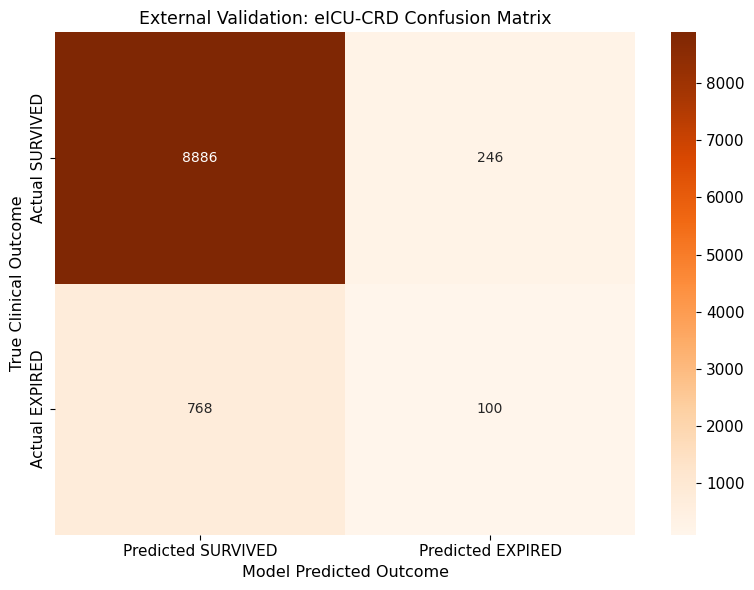

Saved external prediction results: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_results.csv
Saved external class-wise metrics: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_classwise_metrics.csv
Saved external clinical risk audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_clinical_risk_audit.csv
Saved JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_metrics.json
Results CSV             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_results.csv
Class-wise metrics CSV  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_classwise_metrics.csv
Clinical risk audit CSV : C:\Users\927997\OneDrive - hull.a

In [5]:
# =====================================================================
# Step 2: Model Deployment and External Performance Quantification
# =====================================================================

# ---------------------------------------------------------
# 0) Guard: Upstream Dependency Check
# ---------------------------------------------------------

if "test_sample" not in globals() or not isinstance(test_sample, pd.DataFrame) or len(test_sample) == 0:
    raise RuntimeError("test_sample is missing or empty. Run Step 1 first.")

required_sample_cols = {
    "external_id",
    "ground_truth",
    "admission_diagnosis",
    "heartrate",
    "o2_sat",
    "temperature",
    "sbp",
    "dbp",
}

missing_sample_cols = sorted(required_sample_cols - set(test_sample.columns))

if missing_sample_cols:
    raise KeyError(
        "test_sample is missing required external evaluation columns:\n"
        f"  {missing_sample_cols}"
    )

if "ADAPTER_PATH" not in globals() or not Path(ADAPTER_PATH).exists():
    raise RuntimeError("ADAPTER_PATH is missing or invalid. Run the environment setup cell first.")

if "ADAPTER_MANIFEST_PATH" not in globals() or not Path(ADAPTER_MANIFEST_PATH).exists():
    raise RuntimeError("ADAPTER_MANIFEST_PATH is missing or invalid. Run the environment setup cell first.")

print("Step 2: Initializing model for eICU external validation...")

# ---------------------------------------------------------
# 1) Model and Tokenizer Loading
# ---------------------------------------------------------

compute_dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    else torch.float16
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

tokenizer_source = (
    ADAPTER_PATH
    if (ADAPTER_PATH / "tokenizer_config.json").exists()
    else BASE_MODEL_ID
)

print(f"Loading tokenizer : {tokenizer_source}")

tokenizer = AutoTokenizer.from_pretrained(
    str(tokenizer_source),
    trust_remote_code=True,
    use_fast=True,
)

if tokenizer.eos_token is None:
    raise ValueError("Tokenizer has no eos_token.")

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print(f"Loading base model : {BASE_MODEL_ID}")
print(f"Adapter path       : {ADAPTER_PATH}")
print(f"Compute dtype      : {compute_dtype}")
print(f"Expired threshold  : {BEST_EXPIRED_THRESHOLD}")

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
    trust_remote_code=True,
    use_safetensors=False,
)

base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.eos_token_id = tokenizer.eos_token_id
base_model.config.bos_token_id = tokenizer.bos_token_id

if hasattr(base_model, "generation_config") and base_model.generation_config is not None:
    base_model.generation_config.pad_token_id = tokenizer.pad_token_id
    base_model.generation_config.eos_token_id = tokenizer.eos_token_id
    base_model.generation_config.bos_token_id = tokenizer.bos_token_id

model = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))
model.eval()

# ---------------------------------------------------------
# 2) eICU Input Formatter
# ---------------------------------------------------------

def _format_value(value, suffix: str = "") -> str:
    if pd.isna(value):
        return "N/A"

    text = str(value).strip()

    if not text or text.lower() in {"nan", "none", "na"}:
        return "N/A"

    return f"{text}{suffix}"


def format_eicu_input(row: pd.Series) -> str:
    """
    Build the external eICU input block. The classification prompt itself is
    created by build_classification_prompt() from the shared utility cell.
    """
    return (
        f"External dataset: eICU-CRD\n"
        f"Admission Diagnosis: {_format_value(row.get('admission_diagnosis', 'N/A'))}\n"
        f"Initial Vitals:\n"
        f"- Temperature: {_format_value(row.get('temperature', np.nan))}\n"
        f"- Heart Rate: {_format_value(row.get('heartrate', np.nan), ' bpm')}\n"
        f"- O2 Saturation: {_format_value(row.get('o2_sat', np.nan), '%')}\n"
        f"- Systolic Blood Pressure: {_format_value(row.get('sbp', np.nan), ' mmHg')}\n"
        f"- Diastolic Blood Pressure: {_format_value(row.get('dbp', np.nan), ' mmHg')}"
    )


COMPUTE_EXTERNAL_PROBABILITIES = bool(
    globals().get("COMPUTE_EXTERNAL_PROBABILITIES", True)
)

MAX_EXTERNAL_PROMPT_LENGTH = int(globals().get("MAX_EXTERNAL_PROMPT_LENGTH", 512))

# ---------------------------------------------------------
# 3) Deterministic External Batch Inference
# ---------------------------------------------------------

results = []

print("Initiating deterministic inference on eICU external cohort...")
print(f"External rows to score      : {len(test_sample):,}")
print(f"Compute label probabilities : {COMPUTE_EXTERNAL_PROBABILITIES}")
print(f"Decision threshold EXPIRED  : {BEST_EXPIRED_THRESHOLD}")

for row_index, row in tqdm(test_sample.reset_index(drop=True).iterrows(), total=len(test_sample)):
    input_text = format_eicu_input(row)
    prompt = build_classification_prompt(input_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_EXTERNAL_PROMPT_LENGTH,
    ).to(_active_model_device())

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            temperature=None,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    raw_prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_tail = extract_generated_response(raw_prediction, prompt=prompt)
    generated_prediction = parse_label(generated_tail)

    ground_truth = parse_label(row.get("ground_truth", "UNKNOWN"))

    prob_payload = {
        "survived_log_likelihood": np.nan,
        "expired_log_likelihood": np.nan,
        "survived_mean_log_likelihood": np.nan,
        "expired_mean_log_likelihood": np.nan,
        "survived_token_count": np.nan,
        "expired_token_count": np.nan,
        "survived_probability": np.nan,
        "expired_probability": np.nan,
        "score_normalized_by_tokens": True,
    }

    threshold_prediction = "UNKNOWN"

    if COMPUTE_EXTERNAL_PROBABILITIES:
        prob_payload = compute_label_probabilities(
            prompt,
            normalize_by_tokens=True,
        )
        threshold_prediction = threshold_label_from_probability(
            prob_payload["expired_probability"],
            threshold=BEST_EXPIRED_THRESHOLD,
        )

    prediction = (
        threshold_prediction
        if threshold_prediction in VALID_LABELS
        else generated_prediction
    )

    prediction_source = (
        "threshold_expired_probability"
        if threshold_prediction in VALID_LABELS
        else "generated_text_fallback"
    )

    y_true = LABEL_TO_ID.get(ground_truth, np.nan)
    y_pred = LABEL_TO_ID.get(prediction, np.nan)

    result_row = {
        "row_index": int(row_index),
        "external_dataset": "eICU-CRD",
        "external_id": row.get("external_id"),
        "patientunitstayid": row.get("patientunitstayid", np.nan),

        "ground_truth": ground_truth,
        "prediction": prediction,
        "prediction_source": prediction_source,
        "generated_prediction": generated_prediction,
        "threshold_prediction": threshold_prediction,

        "reference": f"Outcome: {ground_truth}",
        "generated_tail": generated_tail,
        "raw_prediction": raw_prediction,

        "y_true": y_true,
        "y_pred": y_pred,
        "correct": (
            int(y_true == y_pred)
            if pd.notna(y_true) and pd.notna(y_pred)
            else np.nan
        ),

        "admission_diagnosis": row.get("admission_diagnosis", "N/A"),
        "input_text": input_text,
        "prompt": prompt,

        "heartrate": row.get("heartrate", np.nan),
        "o2_sat": row.get("o2_sat", np.nan),
        "temperature": row.get("temperature", np.nan),
        "sbp": row.get("sbp", np.nan),
        "dbp": row.get("dbp", np.nan),

        "survived_log_likelihood": prob_payload["survived_log_likelihood"],
        "expired_log_likelihood": prob_payload["expired_log_likelihood"],
        "survived_mean_log_likelihood": prob_payload["survived_mean_log_likelihood"],
        "expired_mean_log_likelihood": prob_payload["expired_mean_log_likelihood"],
        "survived_token_count": prob_payload["survived_token_count"],
        "expired_token_count": prob_payload["expired_token_count"],
        "survived_probability": prob_payload["survived_probability"],
        "expired_probability": prob_payload["expired_probability"],
        "score_normalized_by_tokens": prob_payload["score_normalized_by_tokens"],
        "best_expired_threshold": float(BEST_EXPIRED_THRESHOLD),

        "model": f"{BASE_MODEL_ID}+LoRA-{ADAPTER_TASK_VARIANT}",
        "model_name": f"{BASE_MODEL_ID}+LoRA-{ADAPTER_TASK_VARIANT}",
        "task_variant": ADAPTER_TASK_VARIANT,

        # Backward-compatible probability aliases.
        "y_prob": prob_payload["expired_probability"],
        "p_expired": prob_payload["expired_probability"],
    }

    for missing_col in [
        "heartrate_missing",
        "o2_sat_missing",
        "temperature_missing",
        "sbp_missing",
        "dbp_missing",
        "any_vital_missing",
        "all_vitals_missing",
    ]:
        if missing_col in row.index:
            result_row[missing_col] = row.get(missing_col)

    results.append(result_row)

external_results_df = pd.DataFrame(results)

# ---------------------------------------------------------
# 4) Metric Computation and Reporting
# ---------------------------------------------------------

external_metrics = compute_binary_metrics(
    external_results_df,
    label_col="ground_truth",
    pred_col="prediction",
    score_col="expired_probability" if COMPUTE_EXTERNAL_PROBABILITIES else None,
)

external_classwise_df = compute_classwise_metrics(
    external_results_df,
    label_col="ground_truth",
    pred_col="prediction",
)

external_risk_df = build_external_risk_audit(
    external_results_df,
    metrics=external_metrics,
    label_col="ground_truth",
    pred_col="prediction",
)

clean_results = external_results_df[
    external_results_df["ground_truth"].isin(VALID_LABELS)
    & external_results_df["prediction"].isin(VALID_LABELS)
].copy()

unknown_ground_truth = int((external_results_df["ground_truth"] == "UNKNOWN").sum())
unknown_prediction = int((external_results_df["prediction"] == "UNKNOWN").sum())
ambiguous_ground_truth = int((external_results_df["ground_truth"] == "AMBIGUOUS").sum())
ambiguous_prediction = int((external_results_df["prediction"] == "AMBIGUOUS").sum())

prediction_source_summary = (
    external_results_df["prediction_source"]
    .fillna("unknown")
    .astype(str)
    .value_counts()
    .to_dict()
)

print("\n" + "=" * 64)
print("EXTERNAL VALIDATION PERFORMANCE - eICU-CRD")
print("=" * 64)
print(f"Adapter task variant          : {ADAPTER_TASK_VARIANT}")
print(f"Adapter response mode         : {ADAPTER_TRAINING_RESPONSE_MODE}")
print(f"Decision threshold EXPIRED    : {BEST_EXPIRED_THRESHOLD}")
print(f"Total scored rows             : {len(external_results_df):,}")
print(f"Rows used for strict metrics  : {len(clean_results):,}")
print(f"Unknown ground-truth rows     : {unknown_ground_truth:,}")
print(f"Unknown prediction rows       : {unknown_prediction:,}")
print(f"Ambiguous ground-truth rows   : {ambiguous_ground_truth:,}")
print(f"Ambiguous prediction rows     : {ambiguous_prediction:,}")
print(f"Prediction source summary     : {prediction_source_summary}")
print(f"Accuracy                      : {external_metrics['accuracy']:.6f}")
print(f"Balanced accuracy             : {external_metrics['balanced_accuracy']:.6f}")
print(f"Macro F1                      : {external_metrics['macro_f1']:.6f}")
print(f"EXPIRED precision             : {external_metrics['expired_precision']:.6f}")
print(f"EXPIRED recall                : {external_metrics['expired_recall']:.6f}")
print(f"EXPIRED F1                    : {external_metrics['expired_f1']:.6f}")
print(f"SURVIVED recall               : {external_metrics['survived_recall']:.6f}")
print(f"AUROC                         : {external_metrics['auroc']}")
print(f"AUPRC                         : {external_metrics['auprc']}")

report_text = classification_report(
    clean_results["ground_truth"],
    clean_results["prediction"],
    labels=VALID_LABELS,
    zero_division=0,
)

print(report_text)

cm = confusion_matrix(
    clean_results["ground_truth"],
    clean_results["prediction"],
    labels=VALID_LABELS,
)

# ---------------------------------------------------------
# 5) Confusion Matrix Visualization
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Predicted SURVIVED", "Predicted EXPIRED"],
    yticklabels=["Actual SURVIVED", "Actual EXPIRED"],
)

plt.title("External Validation: eICU-CRD Confusion Matrix")
plt.ylabel("True Clinical Outcome")
plt.xlabel("Model Predicted Outcome")
plt.tight_layout()

cm_path = QUALITY_DIR / "phase7_external_confusion_matrix.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# ---------------------------------------------------------
# 6) Artifact Persistence and Audit
# ---------------------------------------------------------

results_csv_path = QUALITY_DIR / "phase7_external_results.csv"
classwise_csv_path = QUALITY_DIR / "phase7_external_classwise_metrics.csv"
risk_csv_path = QUALITY_DIR / "phase7_external_clinical_risk_audit.csv"
metrics_json_path = QUALITY_DIR / "phase7_external_metrics.json"
report_txt_path = QUALITY_DIR / "phase7_external_classification_report.txt"

save_dataframe(external_results_df, results_csv_path, label="external prediction results")
save_dataframe(external_classwise_df, classwise_csv_path, label="external class-wise metrics")
save_dataframe(external_risk_df, risk_csv_path, label="external clinical risk audit")
save_json(external_metrics, metrics_json_path)

with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(report_text)

external_eval_audit.update({
    "tokenizer_source": str(tokenizer_source),
    "base_model_id": BASE_MODEL_ID,
    "adapter_path": str(ADAPTER_PATH),
    "adapter_manifest_path": str(ADAPTER_MANIFEST_PATH),
    "adapter_task_variant": ADAPTER_TASK_VARIANT,
    "adapter_training_response_mode": ADAPTER_TRAINING_RESPONSE_MODE,
    "compute_external_probabilities": COMPUTE_EXTERNAL_PROBABILITIES,
    "best_expired_threshold": float(BEST_EXPIRED_THRESHOLD),
    "threshold_source": THRESHOLD_SOURCE,
    "prediction_source_summary": prediction_source_summary,
    "positive_class": "EXPIRED",
    "score_column": "expired_probability",
    "external_rows_scored": int(len(external_results_df)),
    "rows_used_for_strict_metrics": int(len(clean_results)),
    "unknown_ground_truth_rows": unknown_ground_truth,
    "unknown_prediction_rows": unknown_prediction,
    "ambiguous_ground_truth_rows": ambiguous_ground_truth,
    "ambiguous_prediction_rows": ambiguous_prediction,
    "metrics": external_metrics,
    "confusion_matrix_png": str(cm_path),
    "results_csv": str(results_csv_path),
    "classwise_metrics_csv": str(classwise_csv_path),
    "clinical_risk_audit_csv": str(risk_csv_path),
    "metrics_json": str(metrics_json_path),
    "classification_report_txt": str(report_txt_path),
})

print(f"Results CSV             : {results_csv_path}")
print(f"Class-wise metrics CSV  : {classwise_csv_path}")
print(f"Clinical risk audit CSV : {risk_csv_path}")
print(f"Metrics JSON            : {metrics_json_path}")
print(f"Classification report   : {report_txt_path}")
print(f"Confusion matrix PNG    : {cm_path}")
print("Step 2 completed successfully.")


**Step 3: External Diagnostics and Internal-vs-External Audit**

This step analyzes the external eICU results against the internal Notebook 06 baseline. It evaluates label validity, strict metric eligibility, class-wise performance shifts, clinical-risk shifts, and feature missingness patterns that may indicate domain shift.

**Main Operations**  
◽ Resolve the external prediction table from memory or saved CSV outputs  
◽ Load the required Notebook 06 internal baseline artifacts  
◽ Validate required prediction and label columns for both internal and external results  
◽ Summarize external label validity and unknown or invalid predictions  
◽ Compare class-wise metrics between eICU and the internal MIMIC test set  
◽ Compare clinical-risk audit patterns across internal and external results  
◽ Calculate feature missingness rates in the external cohort  
◽ Export label governance, class-wise shift, risk-shift, missingness, and diagnostics payload files  

**Technical and Clinical Significance**  
External validation should not rely only on a single accuracy value. Comparing label quality, class-wise recall, risk patterns, and missingness helps identify whether the model fails differently under eICU distribution shift than it did on the internal MIMIC test set.

**Expected Outcome**  
External diagnostics and internal-vs-external comparison artifacts are saved, including label governance, class-wise shift, clinical-risk shift, feature missingness, and diagnostic payload files.

In [6]:
# =====================================================================
# Step 3: External Validation Diagnostics and Internal-vs-External Audit
# =====================================================================

print("Step 3: Running external validation diagnostics...")

# ---------------------------------------------------------
# 0) Guard: External Results and Phase 06 Baseline Resolution
# ---------------------------------------------------------

external_results_df, external_source = resolve_external_results(step_label="Step 3")
phase6_artifacts = load_phase6_baseline_artifacts()

phase6_results_df = phase6_artifacts["batch_results"]
phase6_risk_df = phase6_artifacts["risk_audit"]
phase6_classwise_df = phase6_artifacts["classwise_metrics"]
phase6_model_board_df = phase6_artifacts["model_board"]

print(f"External results resolved : {external_source}  (rows={len(external_results_df):,})")
print(f"Phase 06 baseline rows    : {len(phase6_results_df):,}")

required_external_cols = {"ground_truth", "prediction", "y_true", "y_pred"}
missing_external_cols = sorted(required_external_cols - set(external_results_df.columns))

if missing_external_cols:
    raise KeyError(
        "External results are missing required Notebook 07 columns:\n"
        f"  {missing_external_cols}"
    )

required_phase6_cols = {"ground_truth", "prediction"}
missing_phase6_cols = sorted(required_phase6_cols - set(phase6_results_df.columns))

if missing_phase6_cols:
    raise KeyError(
        "Phase 06 batch results are missing required baseline columns:\n"
        f"  {missing_phase6_cols}"
    )

# ---------------------------------------------------------
# 1) Label Governance Summary
# ---------------------------------------------------------

external_total = int(len(external_results_df))

external_strict = external_results_df[
    external_results_df["ground_truth"].isin(VALID_LABELS)
    & external_results_df["prediction"].isin(VALID_LABELS)
].copy()

phase6_strict = phase6_results_df[
    phase6_results_df["ground_truth"].isin(VALID_LABELS)
    & phase6_results_df["prediction"].isin(VALID_LABELS)
].copy()

phase6_threshold = (
    float(pd.to_numeric(phase6_results_df["best_expired_threshold"], errors="coerce").dropna().iloc[0])
    if "best_expired_threshold" in phase6_results_df.columns
    and len(pd.to_numeric(phase6_results_df["best_expired_threshold"], errors="coerce").dropna()) > 0
    else np.nan
)

external_threshold = (
    float(pd.to_numeric(external_results_df["best_expired_threshold"], errors="coerce").dropna().iloc[0])
    if "best_expired_threshold" in external_results_df.columns
    and len(pd.to_numeric(external_results_df["best_expired_threshold"], errors="coerce").dropna()) > 0
    else float(globals().get("BEST_EXPIRED_THRESHOLD", 0.5))
)

phase6_prediction_source = (
    phase6_results_df["prediction_source"].fillna("unknown").astype(str).value_counts().to_dict()
    if "prediction_source" in phase6_results_df.columns
    else {}
)

external_prediction_source = (
    external_results_df["prediction_source"].fillna("unknown").astype(str).value_counts().to_dict()
    if "prediction_source" in external_results_df.columns
    else {}
)

label_governance_rows = [
    {
        "dataset": "internal_mimic_phase6",
        "metric": "rows_total",
        "value": int(len(phase6_results_df)),
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "rows_strict",
        "value": int(len(phase6_strict)),
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "expired_support",
        "value": int((phase6_strict["ground_truth"] == "EXPIRED").sum()),
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "survived_support",
        "value": int((phase6_strict["ground_truth"] == "SURVIVED").sum()),
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "expired_rate_pct",
        "value": round(float((phase6_strict["ground_truth"] == "EXPIRED").mean() * 100.0), 3)
        if len(phase6_strict) else np.nan,
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "best_expired_threshold",
        "value": phase6_threshold,
    },
    {
        "dataset": "internal_mimic_phase6",
        "metric": "prediction_source_summary",
        "value": json.dumps(phase6_prediction_source),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "rows_total",
        "value": external_total,
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "rows_strict",
        "value": int(len(external_strict)),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "expired_support",
        "value": int((external_strict["ground_truth"] == "EXPIRED").sum()),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "survived_support",
        "value": int((external_strict["ground_truth"] == "SURVIVED").sum()),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "expired_rate_pct",
        "value": round(float((external_strict["ground_truth"] == "EXPIRED").mean() * 100.0), 3)
        if len(external_strict) else np.nan,
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "best_expired_threshold",
        "value": external_threshold,
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "prediction_source_summary",
        "value": json.dumps(external_prediction_source),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "unknown_prediction_rows",
        "value": int((external_results_df["prediction"] == "UNKNOWN").sum()),
    },
    {
        "dataset": "external_eicu_phase7",
        "metric": "ambiguous_prediction_rows",
        "value": int((external_results_df["prediction"] == "AMBIGUOUS").sum()),
    },
]

label_governance_df = pd.DataFrame(label_governance_rows)

label_governance_path = QUALITY_DIR / "phase7_external_label_governance_summary.csv"

save_dataframe(
    label_governance_df,
    label_governance_path,
    label="external label governance summary",
)

# ---------------------------------------------------------
# 2) Internal-vs-External Class-Wise Shift
# ---------------------------------------------------------

external_classwise_df = compute_classwise_metrics(
    external_results_df,
    label_col="ground_truth",
    pred_col="prediction",
)

phase6_classwise_norm = phase6_classwise_df.copy()

if "class" not in phase6_classwise_norm.columns or "recall" not in phase6_classwise_norm.columns:
    raise KeyError(
        "phase6_classwise_metrics.csv must contain at least 'class' and 'recall' columns."
    )

class_shift_df = external_classwise_df.merge(
    phase6_classwise_norm[["class", "support", "correct", "recall"]],
    on="class",
    how="outer",
    suffixes=("_external", "_internal"),
)

class_shift_df["delta_recall_external_minus_internal"] = (
    pd.to_numeric(class_shift_df["recall_external"], errors="coerce")
    - pd.to_numeric(class_shift_df["recall_internal"], errors="coerce")
).round(6)

class_shift_df["support_delta_external_minus_internal"] = (
    pd.to_numeric(class_shift_df["support_external"], errors="coerce")
    - pd.to_numeric(class_shift_df["support_internal"], errors="coerce")
)

class_shift_path = QUALITY_DIR / "phase7_external_classwise_shift_vs_phase6.csv"

save_dataframe(
    class_shift_df,
    class_shift_path,
    label="external class-wise shift board",
)

# ---------------------------------------------------------
# 3) Risk Carry-Over and External Risk Summary
# ---------------------------------------------------------

external_metrics = compute_binary_metrics(
    external_results_df,
    label_col="ground_truth",
    pred_col="prediction",
    score_col="expired_probability" if "expired_probability" in external_results_df.columns else None,
)

external_risk_df = build_external_risk_audit(
    external_results_df,
    metrics=external_metrics,
    label_col="ground_truth",
    pred_col="prediction",
)

phase6_risk_compact = phase6_risk_df.copy()

if "check" not in phase6_risk_compact.columns:
    raise KeyError("phase6_clinical_risk_audit.csv must contain a 'check' column.")

phase6_risk_compact = phase6_risk_compact.rename(
    columns={
        "value": "internal_value",
        "status": "internal_status",
        "note": "internal_note",
    }
)

external_risk_compact = external_risk_df.rename(
    columns={
        "value": "external_value",
        "status": "external_status",
        "note": "external_note",
    }
)

risk_shift_df = external_risk_compact.merge(
    phase6_risk_compact[
        [
            c for c in [
                "check",
                "internal_value",
                "threshold",
                "internal_status",
                "internal_note",
            ]
            if c in phase6_risk_compact.columns
        ]
    ],
    on="check",
    how="outer",
    suffixes=("_external", "_internal"),
)

if "external_value" in risk_shift_df.columns and "internal_value" in risk_shift_df.columns:
    risk_shift_df["delta_external_minus_internal"] = (
        pd.to_numeric(risk_shift_df["external_value"], errors="coerce")
        - pd.to_numeric(risk_shift_df["internal_value"], errors="coerce")
    ).round(6)

risk_shift_path = QUALITY_DIR / "phase7_external_risk_shift_vs_phase6.csv"

save_dataframe(
    risk_shift_df,
    risk_shift_path,
    label="external risk shift board",
)

# ---------------------------------------------------------
# 4) Missingness and Source-Feature Diagnostics
# ---------------------------------------------------------

source_feature_cols = [
    "admission_diagnosis",
    "heartrate",
    "o2_sat",
    "temperature",
    "sbp",
    "dbp",
    "heartrate_missing",
    "o2_sat_missing",
    "temperature_missing",
    "sbp_missing",
    "dbp_missing",
    "any_vital_missing",
    "all_vitals_missing",
    "expired_probability",
    "survived_probability",
    "prediction_source",
]

missingness_rows = []

for col in source_feature_cols:
    if col not in external_results_df.columns:
        missingness_rows.append({
            "column": col,
            "present": 0,
            "missing_pct": np.nan,
            "non_missing_rows": 0,
        })
        continue

    s = external_results_df[col]

    if pd.api.types.is_string_dtype(s):
        missing_pct = float(s.fillna("").astype(str).str.strip().eq("").mean() * 100.0)
    else:
        missing_pct = float(s.isna().mean() * 100.0)

    missingness_rows.append({
        "column": col,
        "present": 1,
        "missing_pct": round(missing_pct, 3),
        "non_missing_rows": int(s.notna().sum()),
    })

missingness_df = pd.DataFrame(missingness_rows)

missingness_path = QUALITY_DIR / "phase7_external_feature_missingness.csv"

save_dataframe(
    missingness_df,
    missingness_path,
    label="external feature missingness audit",
)

# ---------------------------------------------------------
# 5) Compact Diagnostic Payload
# ---------------------------------------------------------

diagnostic_payload = {
    "external_source": external_source,
    "phase6_results_path": str(PHASE6_RESULTS_PATH),
    "phase6_risk_path": str(PHASE6_RISK_PATH),
    "phase6_classwise_path": str(PHASE6_CLASSWISE_PATH),
    "external_rows": int(len(external_results_df)),
    "external_strict_rows": int(len(external_strict)),
    "phase6_rows": int(len(phase6_results_df)),
    "phase6_strict_rows": int(len(phase6_strict)),
    "positive_class": "EXPIRED",
    "score_column": "expired_probability" if "expired_probability" in external_results_df.columns else None,
    "best_expired_threshold": external_threshold,
    "phase6_best_expired_threshold": phase6_threshold,
    "external_prediction_source_summary": external_prediction_source,
    "phase6_prediction_source_summary": phase6_prediction_source,
    "external_metrics": external_metrics,
    "label_governance_csv": str(label_governance_path),
    "classwise_shift_csv": str(class_shift_path),
    "risk_shift_csv": str(risk_shift_path),
    "feature_missingness_csv": str(missingness_path),
}

diagnostic_payload_path = QUALITY_DIR / "phase7_external_diagnostics_payload.json"

save_json(diagnostic_payload, diagnostic_payload_path)

external_eval_audit.update({
    "step3_external_source": external_source,
    "step3_label_governance_csv": str(label_governance_path),
    "step3_classwise_shift_csv": str(class_shift_path),
    "step3_risk_shift_csv": str(risk_shift_path),
    "step3_feature_missingness_csv": str(missingness_path),
    "step3_diagnostics_payload_json": str(diagnostic_payload_path),
    "step3_external_metrics": external_metrics,
    "step3_external_prediction_source_summary": external_prediction_source,
})

print("Step 3 completed successfully.")
print(f"Label governance : {label_governance_path}")
print(f"Class-wise shift : {class_shift_path}")
print(f"Risk shift       : {risk_shift_path}")
print(f"Missingness      : {missingness_path}")


Step 3: Running external validation diagnostics...
External results resolved : external_results_df  (rows=10,000)
Phase 06 baseline rows    : 5,368
Saved external label governance summary: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_label_governance_summary.csv
Saved external class-wise shift board: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_classwise_shift_vs_phase6.csv
Saved external risk shift board: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_risk_shift_vs_phase6.csv
Saved external feature missingness audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_feature_missingness.csv
Saved JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_diagnostics_payload.js

**Step 4: Internal-vs-External Performance Shift and Drift Alerts**

This step builds a formal performance-shift board by comparing external eICU metrics with the internal Notebook 06 benchmark. It calculates metric deltas, visualizes internal-versus-external performance, and flags clinically relevant drops as drift alerts.

**Main Operations**  
◽ Resolve the external prediction table and Phase 06 model-comparison board  
◽ Compute external binary classification metrics using available probability scores  
◽ Build an external model-comparison row for the evaluated adapter  
◽ Align internal and external metrics for direct comparison  
◽ Calculate external-minus-internal metric deltas  
◽ Flag performance drops that exceed the configured drift threshold  
◽ Export external model-comparison metrics, metric-shift tables, drift-alert files, and plots  

**Technical and Clinical Significance**  
Metric-shift analysis makes cross-institutional generalization measurable. A performance drop on eICU may indicate covariate shift, documentation differences, population differences, or model overfitting to the original MIMIC-based development setting.

**Expected Outcome**  
The notebook saves `phase7_external_model_comparison_metrics.csv`, `phase7_external_metric_shift_vs_phase6.csv`, `phase7_external_drift_alerts.csv`, and the corresponding metric-shift visualization.

Step 4: Building internal-vs-external performance shift board...
External source resolved : external_results_df  (rows=10,000)
Internal board rows      : 1
Saved external model comparison board: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_model_comparison_metrics.csv
Internal baseline match mode : task_variant
Internal model               : BioMistral/BioMistral-7B+LoRA-retrospective
Saved external metric shift board: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_metric_shift_vs_phase6.csv
Saved external drift alerts: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_drift_alerts.csv


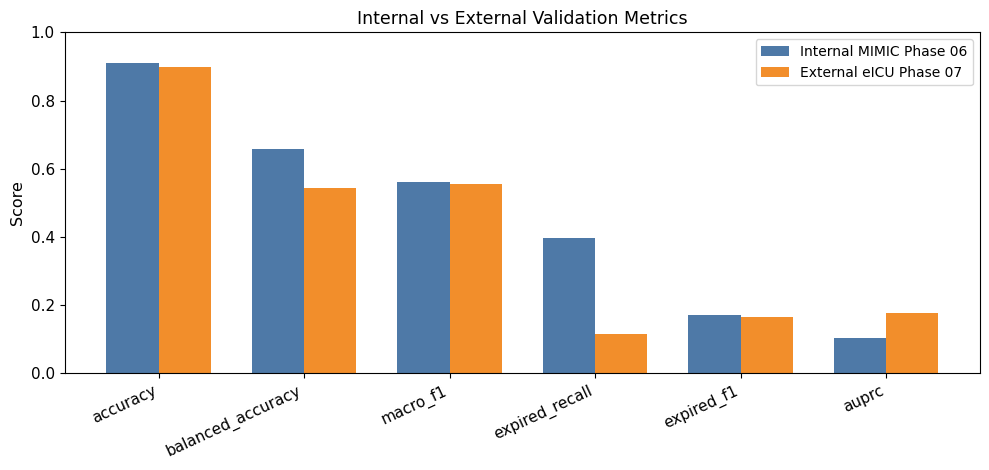

Saved JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_metric_shift_payload.json
Step 4 completed successfully.
External board : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_model_comparison_metrics.csv
Shift board    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_metric_shift_vs_phase6.csv
Drift alerts   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\phase7_external_drift_alerts.csv


In [7]:
# =====================================================================
# Step 4: Internal-vs-External Performance Shift and Drift Alerts
# =====================================================================

print("Step 4: Building internal-vs-external performance shift board...")

# ---------------------------------------------------------
# 0) Guard: External Results and Phase 06 Baseline Resolution
# ---------------------------------------------------------

external_results_df, external_source = resolve_external_results(step_label="Step 4")
phase6_artifacts = load_phase6_baseline_artifacts()

phase6_model_board_df = phase6_artifacts["model_board"]
phase6_eval_audit = phase6_artifacts["evaluation_audit"]

if len(phase6_model_board_df) == 0:
    raise RuntimeError("Phase 06 model comparison board is empty.")

print(f"External source resolved : {external_source}  (rows={len(external_results_df):,})")
print(f"Internal board rows      : {len(phase6_model_board_df):,}")

# ---------------------------------------------------------
# 1) External Board Construction
# ---------------------------------------------------------

score_col = (
    "expired_probability"
    if "expired_probability" in external_results_df.columns
    else ("y_prob" if "y_prob" in external_results_df.columns else None)
)

external_metrics = compute_binary_metrics(
    external_results_df,
    label_col="ground_truth",
    pred_col="prediction",
    score_col=score_col,
)

model_name = (
    external_results_df["model_name"].dropna().astype(str).iloc[0]
    if "model_name" in external_results_df.columns
    and external_results_df["model_name"].notna().any()
    else f"{BASE_MODEL_ID}+LoRA-{ADAPTER_TASK_VARIANT}"
)

external_threshold = (
    float(pd.to_numeric(external_results_df["best_expired_threshold"], errors="coerce").dropna().iloc[0])
    if "best_expired_threshold" in external_results_df.columns
    and len(pd.to_numeric(external_results_df["best_expired_threshold"], errors="coerce").dropna()) > 0
    else float(globals().get("BEST_EXPIRED_THRESHOLD", 0.5))
)

external_prediction_source_summary = (
    external_results_df["prediction_source"].fillna("unknown").astype(str).value_counts().to_dict()
    if "prediction_source" in external_results_df.columns
    else {}
)

external_board = pd.DataFrame([
    {
        "model": model_name,
        "task_variant": ADAPTER_TASK_VARIANT,
        "source": external_source,
        "dataset": "eICU-CRD",
        "rows_total": int(len(external_results_df)),
        "rows_strict": int(external_metrics["rows_strict"]),
        "prediction_source_summary": json.dumps(external_prediction_source_summary),
        "best_expired_threshold": external_threshold,
        "positive_class": "EXPIRED",
        "score_column": score_col,

        "accuracy": external_metrics["accuracy"],
        "balanced_accuracy": external_metrics["balanced_accuracy"],

        "macro_precision": external_metrics["macro_precision"],
        "macro_recall": external_metrics["macro_recall"],
        "macro_f1": external_metrics["macro_f1"],

        "weighted_precision": external_metrics["weighted_precision"],
        "weighted_recall": external_metrics["weighted_recall"],
        "weighted_f1": external_metrics["weighted_f1"],

        "survived_precision": external_metrics["survived_precision"],
        "survived_recall": external_metrics["survived_recall"],
        "survived_f1": external_metrics["survived_f1"],
        "survived_support": external_metrics["survived_support"],

        "expired_precision": external_metrics["expired_precision"],
        "expired_recall": external_metrics["expired_recall"],
        "expired_f1": external_metrics["expired_f1"],
        "expired_support": external_metrics["expired_support"],

        "auroc": external_metrics["auroc"],
        "auprc": external_metrics["auprc"],
        "probability_metric_note": external_metrics["probability_metric_note"],
    }
])

external_board_path = QUALITY_DIR / "phase7_external_model_comparison_metrics.csv"

save_dataframe(
    external_board,
    external_board_path,
    label="external model comparison board",
)

# ---------------------------------------------------------
# 2) Internal Baseline Row Resolution
# ---------------------------------------------------------

internal_board = phase6_model_board_df.copy()

if "task_variant" in internal_board.columns:
    task_match = internal_board[
        internal_board["task_variant"].astype(str) == str(ADAPTER_TASK_VARIANT)
    ].copy()
else:
    task_match = pd.DataFrame()

if len(task_match) > 0:
    internal_row = task_match.iloc[0].to_dict()
    internal_match_mode = "task_variant"
else:
    internal_row = internal_board.iloc[0].to_dict()
    internal_match_mode = "first_available_phase6_row"

internal_dataset_path = phase6_eval_audit.get("dataset_path", "unknown")
internal_model_name = internal_row.get("model", "phase6_internal_baseline")

internal_threshold = pd.to_numeric(
    pd.Series([internal_row.get("best_expired_threshold")]),
    errors="coerce",
).iloc[0]

print(f"Internal baseline match mode : {internal_match_mode}")
print(f"Internal model               : {internal_model_name}")

# ---------------------------------------------------------
# 3) Shift Delta Computation
# ---------------------------------------------------------

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "survived_precision",
    "survived_recall",
    "survived_f1",
    "expired_precision",
    "expired_recall",
    "expired_f1",
    "auroc",
    "auprc",
]

shift_rows = []

for metric in metric_names:
    internal_value = pd.to_numeric(
        pd.Series([internal_row.get(metric)]),
        errors="coerce",
    ).iloc[0]

    external_value = pd.to_numeric(
        pd.Series([external_board.loc[0, metric]]),
        errors="coerce",
    ).iloc[0]

    if pd.notna(internal_value) and pd.notna(external_value):
        delta = round(float(external_value - internal_value), 6)
    else:
        delta = np.nan

    if metric in {"expired_recall", "expired_f1", "macro_f1", "balanced_accuracy", "auroc", "auprc"}:
        alert_threshold = -0.03
    else:
        alert_threshold = -0.05

    shift_rows.append({
        "metric": metric,
        "internal_value": round(float(internal_value), 6) if pd.notna(internal_value) else np.nan,
        "external_value": round(float(external_value), 6) if pd.notna(external_value) else np.nan,
        "delta_external_minus_internal": delta,
        "alert_threshold": alert_threshold,
        "alert_drop": int(pd.notna(delta) and delta < alert_threshold),
    })

shift_board = pd.DataFrame(shift_rows)

shift_board_path = QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.csv"

save_dataframe(
    shift_board,
    shift_board_path,
    label="external metric shift board",
)

# ---------------------------------------------------------
# 4) Drift Alert Summary
# ---------------------------------------------------------

high_priority_metrics = {
    "balanced_accuracy",
    "macro_f1",
    "expired_recall",
    "expired_f1",
    "auroc",
    "auprc",
}

alert_rows = shift_board[
    (shift_board["alert_drop"] == 1)
    | (
        shift_board["metric"].isin(high_priority_metrics)
        & shift_board["external_value"].notna()
        & (shift_board["external_value"] < 0.65)
    )
].copy()

alert_rows["alert_reason"] = alert_rows.apply(
    lambda r: (
        "external_metric_below_0_65"
        if r["metric"] in high_priority_metrics
        and pd.notna(r["external_value"])
        and float(r["external_value"]) < 0.65
        else "external_drop_exceeds_threshold"
    ),
    axis=1,
)

alert_path = QUALITY_DIR / "phase7_external_drift_alerts.csv"

save_dataframe(
    alert_rows,
    alert_path,
    label="external drift alerts",
)

# ---------------------------------------------------------
# 5) Visualization
# ---------------------------------------------------------

plot_metrics = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "expired_recall",
    "expired_f1",
    "auprc",
]

plot_df = shift_board[shift_board["metric"].isin(plot_metrics)].copy()

if len(plot_df) > 0:
    x = np.arange(len(plot_df))
    width = 0.36

    plt.figure(figsize=(10, 4.8))

    plt.bar(
        x - width / 2,
        plot_df["internal_value"].fillna(0).astype(float),
        width,
        label="Internal MIMIC Phase 06",
        color="#4E79A7",
    )

    plt.bar(
        x + width / 2,
        plot_df["external_value"].fillna(0).astype(float),
        width,
        label="External eICU Phase 07",
        color="#F28E2B",
    )

    plt.ylim(0, 1)
    plt.xticks(x, plot_df["metric"], rotation=25, ha="right")
    plt.ylabel("Score")
    plt.title("Internal vs External Validation Metrics")
    plt.legend()
    plt.tight_layout()

    shift_fig_path = QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.png"
    plt.savefig(shift_fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    shift_fig_path = None

# ---------------------------------------------------------
# 6) Payload and Audit Update
# ---------------------------------------------------------

payload = {
    "external_source": external_source,
    "external_board_csv": str(external_board_path),
    "internal_board_csv": str(PHASE6_MODEL_BOARD_PATH),
    "internal_dataset_path": internal_dataset_path,
    "internal_match_mode": internal_match_mode,
    "internal_model": str(internal_model_name),
    "external_model": str(model_name),
    "task_variant": ADAPTER_TASK_VARIANT,
    "positive_class": "EXPIRED",
    "score_column": score_col,
    "internal_best_expired_threshold": (
        None if pd.isna(internal_threshold) else float(internal_threshold)
    ),
    "external_best_expired_threshold": float(external_threshold),
    "external_prediction_source_summary": external_prediction_source_summary,
    "shift_board_csv": str(shift_board_path),
    "alert_csv": str(alert_path),
    "figure": str(shift_fig_path) if shift_fig_path else None,
    "alert_count": int(len(alert_rows)),
    "metrics_compared": int(len(shift_board)),
    "high_priority_metrics": sorted(high_priority_metrics),
}

payload_path = QUALITY_DIR / "phase7_external_metric_shift_payload.json"

save_json(payload, payload_path)

external_eval_audit.update({
    "step4_external_board_csv": str(external_board_path),
    "step4_shift_board_csv": str(shift_board_path),
    "step4_drift_alerts_csv": str(alert_path),
    "step4_metric_shift_payload_json": str(payload_path),
    "step4_metric_shift_figure": str(shift_fig_path) if shift_fig_path else None,
    "step4_alert_count": int(len(alert_rows)),
    "step4_external_best_expired_threshold": float(external_threshold),
    "step4_external_prediction_source_summary": external_prediction_source_summary,
})

print("Step 4 completed successfully.")
print(f"External board : {external_board_path}")
print(f"Shift board    : {shift_board_path}")
print(f"Drift alerts   : {alert_path}")


**Step 5: Final External Validation Audit Consolidation**

This step consolidates the main Notebook 07 outputs into a final audit report. It checks whether expected artifacts from cohort extraction, external inference, diagnostics, and metric-shift analysis were created, then records their paths, file sizes, row counts, and completion status.

**Main Operations**  
◽ Validate that the external validation audit object is available  
◽ Confirm that the Notebook 05 adapter path and Notebook 06 audit path still exist  
◽ Register all expected Notebook 07 artifacts by pipeline step  
◽ Check file existence, file size, CSV row counts, and JSON key structure  
◽ Summarize completed and missing artifact groups  
◽ Save a final audit JSON and artifact-summary CSV  

**Technical and Clinical Significance**  
A consolidated audit report makes the external validation run reviewable and reproducible. It provides a single reference point for checking which artifacts were generated successfully and whether any required output is missing before downstream reporting.

**Expected Outcome**  
The final Notebook 07 audit file `notebook_07_external_validation_audit.json` and artifact summary table are saved.

In [8]:
# =====================================================================
# Step 5: Final Audit Consolidation
# =====================================================================

print("Step 5: Consolidating Notebook 07 audit traceability...")

# ---------------------------------------------------------
# 0) Guard: Audit Dictionary and Core Dependencies
# ---------------------------------------------------------

if "external_eval_audit" not in globals() or not isinstance(external_eval_audit, dict):
    raise RuntimeError(
        "external_eval_audit is missing or invalid. "
        "Run the environment setup and previous Notebook 07 steps first."
    )

if "ADAPTER_PATH" not in globals() or not Path(ADAPTER_PATH).exists():
    raise RuntimeError("ADAPTER_PATH is missing or invalid.")

if "PHASE6_AUDIT_PATH" not in globals() or not Path(PHASE6_AUDIT_PATH).exists():
    raise RuntimeError("PHASE6_AUDIT_PATH is missing or invalid.")

# ---------------------------------------------------------
# 1) Notebook 07 Expected Artifact Registry
# ---------------------------------------------------------

notebook07_artifacts = {
    "step_01_external_eicu_cohort": {
        "csv": OUTPUTS_DIR / "external_eicu_cohort_07.csv",
        "secondary_csv": OUTPUTS_DIR / "external_eicu_eval_sample_07.csv",
    },
    "step_02_external_inference": {
        "csv": QUALITY_DIR / "phase7_external_results.csv",
        "json": QUALITY_DIR / "phase7_external_metrics.json",
        "figure": QUALITY_DIR / "phase7_external_confusion_matrix.png",
        "secondary_csv": QUALITY_DIR / "phase7_external_classwise_metrics.csv",
        "risk_csv": QUALITY_DIR / "phase7_external_clinical_risk_audit.csv",
        "report_txt": QUALITY_DIR / "phase7_external_classification_report.txt",
    },
    "step_03_external_diagnostics": {
        "csv": QUALITY_DIR / "phase7_external_label_governance_summary.csv",
        "json": QUALITY_DIR / "phase7_external_diagnostics_payload.json",
        "secondary_csv": QUALITY_DIR / "phase7_external_classwise_shift_vs_phase6.csv",
        "risk_csv": QUALITY_DIR / "phase7_external_risk_shift_vs_phase6.csv",
        "missingness_csv": QUALITY_DIR / "phase7_external_feature_missingness.csv",
    },
    "step_04_external_shift_alerts": {
        "csv": QUALITY_DIR / "phase7_external_model_comparison_metrics.csv",
        "json": QUALITY_DIR / "phase7_external_metric_shift_payload.json",
        "figure": QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.png",
        "secondary_csv": QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.csv",
        "alert_csv": QUALITY_DIR / "phase7_external_drift_alerts.csv",
    },
}

def audit_file_entry(path: Path) -> dict:
    """Create a compact file audit entry for CSV/JSON/TXT/PNG artifacts."""
    path = Path(path)

    entry = {
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": int(path.stat().st_size) if path.exists() else 0,
    }

    if path.exists() and path.suffix.lower() == ".csv":
        try:
            entry["row_count"] = int(len(pd.read_csv(path)))
        except Exception:
            entry["row_count"] = -1

    if path.exists() and path.suffix.lower() == ".json":
        try:
            with open(path, "r", encoding="utf-8") as f:
                payload = json.load(f)

            entry["json_keys"] = sorted(payload.keys()) if isinstance(payload, dict) else []

            if isinstance(payload, dict):
                entry["json_compact_summary"] = {
                    k: payload.get(k)
                    for k in [
                        "task_variant",
                        "readiness_status",
                        "rows_strict",
                        "accuracy",
                        "balanced_accuracy",
                        "macro_f1",
                        "expired_precision",
                        "expired_recall",
                        "expired_f1",
                        "auroc",
                        "auprc",
                        "best_expired_threshold",
                        "positive_class",
                        "score_column",
                    ]
                    if k in payload
                }

        except Exception:
            entry["json_keys"] = []

    return entry

# ---------------------------------------------------------
# 2) Artifact Coverage Summary
# ---------------------------------------------------------

artifact_audit = {}
summary_rows = []

for step_name, outputs in notebook07_artifacts.items():
    step_entry = {}
    required_roles = {"csv", "json"}
    required_existing = []

    for artifact_role, artifact_path in outputs.items():
        file_entry = audit_file_entry(artifact_path)
        step_entry[artifact_role] = file_entry

        if artifact_role in required_roles:
            required_existing.append(
                bool(file_entry["exists"] and file_entry["size_bytes"] > 0)
            )

        summary_rows.append({
            "step": step_name,
            "artifact_role": artifact_role,
            "path": str(artifact_path),
            "exists": int(file_entry["exists"]),
            "size_bytes": file_entry["size_bytes"],
            "row_count": file_entry.get("row_count", None),
        })

    step_entry["completed"] = int(all(required_existing)) if required_existing else 0
    artifact_audit[step_name] = step_entry

summary_df = pd.DataFrame(summary_rows)

completed_steps = [
    step_name for step_name, step_entry in artifact_audit.items()
    if step_entry["completed"] == 1
]

missing_steps = [
    step_name for step_name, step_entry in artifact_audit.items()
    if step_entry["completed"] != 1
]

# ---------------------------------------------------------
# 3) Pull final external metrics when available
# ---------------------------------------------------------

final_external_metrics = {}

metrics_path = QUALITY_DIR / "phase7_external_metrics.json"

if metrics_path.exists():
    try:
        with open(metrics_path, "r", encoding="utf-8") as f:
            final_external_metrics = json.load(f)
    except Exception as exc:
        final_external_metrics = {"parse_error": type(exc).__name__}

external_board_path = QUALITY_DIR / "phase7_external_model_comparison_metrics.csv"
external_board_summary = {}

if external_board_path.exists():
    try:
        board_df = pd.read_csv(external_board_path)
        if len(board_df) > 0:
            row = board_df.iloc[0].to_dict()
            external_board_summary = {
                k: row.get(k)
                for k in [
                    "rows_total",
                    "rows_strict",
                    "accuracy",
                    "balanced_accuracy",
                    "macro_f1",
                    "expired_precision",
                    "expired_recall",
                    "expired_f1",
                    "auroc",
                    "auprc",
                    "best_expired_threshold",
                    "prediction_source_summary",
                ]
                if k in row
            }
    except Exception as exc:
        external_board_summary = {"parse_error": type(exc).__name__}

# ---------------------------------------------------------
# 4) Final Audit Payload
# ---------------------------------------------------------

final_status = "Success" if len(missing_steps) == 0 else "Incomplete"

external_eval_audit.update({
    "final_execution_status": final_status,
    "notebook07_artifacts": artifact_audit,
    "artifact_coverage_summary": {
        "total_steps": int(len(notebook07_artifacts)),
        "completed_steps": int(len(completed_steps)),
        "missing_or_incomplete_steps": int(len(missing_steps)),
        "completion_pct": round(
            len(completed_steps) / max(len(notebook07_artifacts), 1) * 100.0,
            1,
        ),
        "completed": completed_steps,
        "missing_or_incomplete": missing_steps,
    },
    "adapter_contract": {
        "adapter_path": str(ADAPTER_PATH),
        "adapter_manifest_path": str(ADAPTER_MANIFEST_PATH),
        "adapter_task_variant": ADAPTER_TASK_VARIANT,
        "adapter_training_response_mode": globals().get(
            "ADAPTER_TRAINING_RESPONSE_MODE",
            "classification_only",
        ),
        "base_model_id": BASE_MODEL_ID,
    },
    "phase6_baseline_contract": {
        "pipeline_audit_unified_06": str(PHASE6_AUDIT_PATH),
        "phase6_evaluation_audit": str(PHASE6_EVAL_AUDIT_PATH),
        "phase6_batch_results": str(PHASE6_RESULTS_PATH),
        "phase6_clinical_risk_audit": str(PHASE6_RISK_PATH),
        "phase6_classwise_metrics": str(PHASE6_CLASSWISE_PATH),
        "xai_model_comparison_metrics": str(PHASE6_MODEL_BOARD_PATH),
    },
    "prediction_contract": {
        "training_response_mode": globals().get(
            "ADAPTER_TRAINING_RESPONSE_MODE",
            "classification_only",
        ),
        "positive_class": "EXPIRED",
        "score_column": "expired_probability",
        "decision_rule": "EXPIRED if expired_probability >= BEST_EXPIRED_THRESHOLD else SURVIVED",
        "best_expired_threshold": float(globals().get("BEST_EXPIRED_THRESHOLD", 0.5)),
        "threshold_source": globals().get("THRESHOLD_SOURCE", "unknown"),
        "generation_text_used_for_primary_prediction": False,
    },
    "primary_metric_recommendation": [
        "EXPIRED recall",
        "EXPIRED F1",
        "macro F1",
        "balanced accuracy",
        "AUPRC",
    ],
    "accuracy_warning": (
        "Accuracy is not reliable as the primary metric under severe class imbalance "
        "or external distribution shift."
    ),
    "final_external_metrics": final_external_metrics,
    "external_board_summary": external_board_summary,
    "outputs_path": str(OUTPUTS_DIR),
    "quality_reports_path": str(QUALITY_DIR),
})

# ---------------------------------------------------------
# 5) Artifact Persistence
# ---------------------------------------------------------

final_audit_path = QUALITY_DIR / "notebook_07_external_validation_audit.json"
summary_csv_path = QUALITY_DIR / "notebook_07_external_validation_artifact_summary.csv"

save_json(external_eval_audit, final_audit_path)
save_dataframe(summary_df, summary_csv_path, label="Notebook 07 artifact summary")

if final_status != "Success":
    raise RuntimeError(
        "Notebook 07 final audit is incomplete. Missing/incomplete steps:\n"
        + "\n".join(f"  {step}" for step in missing_steps)
    )

print("Step 5 completed successfully.")
print(f"Final audit JSON : {final_audit_path}")
print(f"Artifact summary : {summary_csv_path}")
print(f"Completion       : {external_eval_audit['artifact_coverage_summary']['completion_pct']}%")


Step 5: Consolidating Notebook 07 audit traceability...
Saved JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_external_validation_audit.json
Saved Notebook 07 artifact summary: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_external_validation_artifact_summary.csv
Step 5 completed successfully.
Final audit JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_external_validation_audit.json
Artifact summary : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_external_validation_artifact_summary.csv
Completion       : 100.0%


**Step 6: Artifact Integrity and Delta Coverage Validation**

This final validation step performs stricter integrity checks on the external validation artifacts. It verifies required files, checks CSV schemas, confirms that metric-shift outputs exist, and validates whether internal-versus-external delta comparisons are complete.

**Main Operations**  
◽ Define the required artifact list for each Notebook 07 pipeline step  
◽ Check whether each required file exists and is non-empty  
◽ Validate required columns in key CSV outputs  
◽ Check JSON files for valid object structure  
◽ Confirm that internal-versus-external delta artifacts are available  
◽ Record missing, empty, unreadable, or schema-invalid files  
◽ Export the final artifact-integrity validation report  

**Technical and Clinical Significance**  
This step acts as a final quality gate for the external validation notebook. It ensures that reported results are backed by complete files with valid schemas, reducing the risk of incomplete comparisons or broken downstream reporting.

**Expected Outcome**  
An artifact-integrity report is saved, documenting whether Notebook 07 outputs are complete, readable, schema-valid, and ready for final project reporting.

In [9]:
# =====================================================================
# Step 6: Artifact Integrity and Delta Coverage Validation
# =====================================================================

print("Step 6: Running Notebook 07 artifact integrity validation...")

# ---------------------------------------------------------
# 0) Required Artifact Registry
# ---------------------------------------------------------

REQUIRED_ARTIFACTS = {
    "step_01_external_eicu_cohort": [
        OUTPUTS_DIR / "external_eicu_cohort_07.csv",
        OUTPUTS_DIR / "external_eicu_eval_sample_07.csv",
    ],
    "step_02_external_inference": [
        QUALITY_DIR / "phase7_external_results.csv",
        QUALITY_DIR / "phase7_external_metrics.json",
        QUALITY_DIR / "phase7_external_confusion_matrix.png",
        QUALITY_DIR / "phase7_external_classwise_metrics.csv",
        QUALITY_DIR / "phase7_external_clinical_risk_audit.csv",
        QUALITY_DIR / "phase7_external_classification_report.txt",
    ],
    "step_03_external_diagnostics": [
        QUALITY_DIR / "phase7_external_label_governance_summary.csv",
        QUALITY_DIR / "phase7_external_classwise_shift_vs_phase6.csv",
        QUALITY_DIR / "phase7_external_risk_shift_vs_phase6.csv",
        QUALITY_DIR / "phase7_external_feature_missingness.csv",
        QUALITY_DIR / "phase7_external_diagnostics_payload.json",
    ],
    "step_04_external_shift_alerts": [
        QUALITY_DIR / "phase7_external_model_comparison_metrics.csv",
        QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.csv",
        QUALITY_DIR / "phase7_external_drift_alerts.csv",
        QUALITY_DIR / "phase7_external_metric_shift_payload.json",
        QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.png",
    ],
    "step_05_final_audit": [
        QUALITY_DIR / "notebook_07_external_validation_audit.json",
        QUALITY_DIR / "notebook_07_external_validation_artifact_summary.csv",
    ],
}

DELTA_ARTIFACTS = [
    QUALITY_DIR / "phase7_external_classwise_shift_vs_phase6.csv",
    QUALITY_DIR / "phase7_external_risk_shift_vs_phase6.csv",
    QUALITY_DIR / "phase7_external_metric_shift_vs_phase6.csv",
]

REQUIRED_RESULT_COLUMNS = {
    "phase7_external_results.csv": {
        "row_index",
        "external_dataset",
        "external_id",
        "ground_truth",
        "prediction",
        "prediction_source",
        "generated_prediction",
        "threshold_prediction",
        "y_true",
        "y_pred",
        "correct",
        "expired_probability",
        "survived_probability",
        "best_expired_threshold",
        "model_name",
        "task_variant",
    },
    "phase7_external_classwise_metrics.csv": {
        "class",
        "support",
        "correct",
        "recall",
    },
    "phase7_external_model_comparison_metrics.csv": {
        "model",
        "task_variant",
        "rows_total",
        "rows_strict",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "expired_precision",
        "expired_recall",
        "expired_f1",
        "auroc",
        "auprc",
        "best_expired_threshold",
    },
    "phase7_external_metric_shift_vs_phase6.csv": {
        "metric",
        "internal_value",
        "external_value",
        "delta_external_minus_internal",
        "alert_drop",
    },
}

# ---------------------------------------------------------
# 1) Artifact Existence, Size, and Schema Checks
# ---------------------------------------------------------

integrity_rows = []
failures = []

def check_artifact(path: Path, step: str) -> dict:
    path = Path(path)

    row = {
        "step": step,
        "file": path.name,
        "path": str(path),
        "exists": int(path.exists()),
        "size_bytes": int(path.stat().st_size) if path.exists() else 0,
        "status": "OK",
        "detail": "",
    }

    if not path.exists():
        row["status"] = "MISSING"
        row["detail"] = "File not found."
        return row

    if path.stat().st_size == 0:
        row["status"] = "EMPTY"
        row["detail"] = "File exists but has zero bytes."
        return row

    if path.suffix.lower() == ".csv":
        try:
            df = pd.read_csv(path)
            row["row_count"] = int(len(df))

            allow_empty_csv = {
                "phase7_external_drift_alerts.csv",
            }

            if len(df) == 0 and path.name not in allow_empty_csv:
                row["status"] = "EMPTY_CSV"
                row["detail"] = "CSV has zero rows."

            required_cols = REQUIRED_RESULT_COLUMNS.get(path.name)

            if required_cols:
                missing_cols = sorted(required_cols - set(df.columns))

                if missing_cols:
                    row["status"] = "SCHEMA_FAIL"
                    row["detail"] = f"Missing columns: {missing_cols}"
                elif row["status"] == "OK":
                    row["detail"] = f"CSV rows={len(df):,}; schema OK."

            elif row["status"] == "OK":
                row["detail"] = f"CSV rows={len(df):,}."

        except Exception as e:
            row["status"] = "READ_ERROR"
            row["detail"] = f"CSV read failed: {e}"

    elif path.suffix.lower() == ".json":
        try:
            with open(path, "r", encoding="utf-8") as f:
                payload = json.load(f)

            if not isinstance(payload, dict):
                row["status"] = "SCHEMA_FAIL"
                row["detail"] = "JSON root is not an object."
            else:
                row["json_key_count"] = int(len(payload))
                row["detail"] = f"JSON keys={len(payload):,}."

        except Exception as e:
            row["status"] = "READ_ERROR"
            row["detail"] = f"JSON read failed: {e}"

    else:
        row["detail"] = f"{path.suffix.lower()} file present."

    return row


for step_name, paths in REQUIRED_ARTIFACTS.items():
    for artifact_path in paths:
        row = check_artifact(artifact_path, step_name)
        integrity_rows.append(row)

        if row["status"] != "OK":
            failures.append(row)

integrity_df = pd.DataFrame(integrity_rows)

# ---------------------------------------------------------
# 2) Delta Coverage Checks
# ---------------------------------------------------------

delta_rows = []
delta_failures = []

for path in DELTA_ARTIFACTS:
    row = {
        "file": path.name,
        "path": str(path),
        "exists": int(path.exists()),
        "total_rows": 0,
        "delta_columns": "",
        "resolved_deltas": 0,
        "status": "OK",
        "detail": "",
    }

    if not path.exists():
        row["status"] = "MISSING"
        row["detail"] = "Delta artifact missing."
        delta_rows.append(row)
        delta_failures.append(row)
        continue

    try:
        df = pd.read_csv(path)
        row["total_rows"] = int(len(df))

        delta_cols = [
            c for c in df.columns
            if c.startswith("delta_") or c == "delta_external_minus_internal"
        ]

        row["delta_columns"] = ",".join(delta_cols)

        if not delta_cols:
            row["status"] = "NO_DELTA_COL"
            row["detail"] = "No delta column found."
            delta_failures.append(row)
        else:
            resolved = int(df[delta_cols].notna().any(axis=1).sum())
            row["resolved_deltas"] = resolved

            if len(df) > 0 and resolved == 0:
                row["status"] = "ALL_NULL"
                row["detail"] = "Delta columns exist but all values are null."
                delta_failures.append(row)
            else:
                row["detail"] = f"{resolved}/{len(df)} rows have at least one resolved delta."

    except Exception as e:
        row["status"] = "READ_ERROR"
        row["detail"] = f"Read failed: {e}"
        delta_failures.append(row)

    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows)

# ---------------------------------------------------------
# 3) Critical Metric Sanity Checks
# ---------------------------------------------------------

sanity_rows = []
sanity_failures = []

metrics_path = QUALITY_DIR / "phase7_external_metrics.json"
results_path = QUALITY_DIR / "phase7_external_results.csv"

if metrics_path.exists():
    metrics_payload = load_json_required(metrics_path, "Notebook 07 external metrics")

    bounded_metric_names = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "expired_precision",
        "expired_recall",
        "expired_f1",
        "survived_recall",
        "auroc",
        "auprc",
    ]

    for metric_name in bounded_metric_names:
        value = metrics_payload.get(metric_name, None)

        status = "OK"
        detail = ""

        if value is None or (isinstance(value, float) and np.isnan(value)):
            if metric_name in {"auroc", "auprc"}:
                status = "OK"
                detail = "Probability metric unavailable or NaN; allowed when class variation is insufficient."
            else:
                status = "MISSING_OR_NON_NUMERIC"
                detail = "Metric missing or non-numeric."
        else:
            try:
                value_float = float(value)

                if value_float < 0.0 or value_float > 1.0:
                    status = "RANGE_FAIL"
                    detail = "Metric outside [0, 1]."
                else:
                    detail = "Metric in valid range."

            except Exception:
                status = "MISSING_OR_NON_NUMERIC"
                detail = "Metric missing or non-numeric."

        row = {
            "check": metric_name,
            "value": value,
            "status": status,
            "detail": detail,
        }

        sanity_rows.append(row)

        if status != "OK":
            sanity_failures.append(row)

    threshold_value = metrics_payload.get(
        "best_expired_threshold",
        globals().get("BEST_EXPIRED_THRESHOLD", None),
    )

    try:
        threshold_float = float(threshold_value)
        threshold_status = "OK" if 0.0 <= threshold_float <= 1.0 else "RANGE_FAIL"
        threshold_detail = "Threshold in valid range." if threshold_status == "OK" else "Threshold outside [0, 1]."
    except Exception:
        threshold_status = "MISSING_OR_NON_NUMERIC"
        threshold_detail = "Threshold missing or non-numeric."

    threshold_row = {
        "check": "best_expired_threshold",
        "value": threshold_value,
        "status": threshold_status,
        "detail": threshold_detail,
    }

    sanity_rows.append(threshold_row)

    if threshold_status != "OK":
        sanity_failures.append(threshold_row)

if results_path.exists():
    results_df_check = pd.read_csv(results_path)

    strict_rows = results_df_check[
        results_df_check["ground_truth"].isin(VALID_LABELS)
        & results_df_check["prediction"].isin(VALID_LABELS)
    ]

    strict_row = {
        "check": "strict_metric_rows",
        "value": int(len(strict_rows)),
        "status": "OK" if len(strict_rows) > 0 else "FAIL",
        "detail": "At least one strict metric row is required.",
    }

    sanity_rows.append(strict_row)

    if strict_row["status"] != "OK":
        sanity_failures.append(strict_row)

    if "prediction_source" in results_df_check.columns:
        source_counts = (
            results_df_check["prediction_source"]
            .fillna("unknown")
            .astype(str)
            .value_counts()
            .to_dict()
        )

        threshold_rows = int(source_counts.get("threshold_expired_probability", 0))

        source_row = {
            "check": "threshold_prediction_source_rows",
            "value": threshold_rows,
            "status": "OK" if threshold_rows > 0 else "REVIEW",
            "detail": f"Prediction source counts: {source_counts}",
        }

        sanity_rows.append(source_row)

        if source_row["status"] != "OK":
            sanity_failures.append(source_row)

    if "expired_probability" in results_df_check.columns:
        prob = pd.to_numeric(results_df_check["expired_probability"], errors="coerce")

        prob_nonnull = int(prob.notna().sum())
        prob_in_range = int(((prob >= 0.0) & (prob <= 1.0)).sum())

        prob_row = {
            "check": "expired_probability_range",
            "value": f"{prob_in_range}/{prob_nonnull}",
            "status": "OK" if prob_nonnull > 0 and prob_in_range == prob_nonnull else "FAIL",
            "detail": "All non-null expired_probability values should be within [0, 1].",
        }

        sanity_rows.append(prob_row)

        if prob_row["status"] != "OK":
            sanity_failures.append(prob_row)

sanity_df = pd.DataFrame(sanity_rows)

# ---------------------------------------------------------
# 4) Persist Validation Reports
# ---------------------------------------------------------

integrity_report_path = QUALITY_DIR / "notebook_07_artifact_integrity_report.csv"
delta_report_path = QUALITY_DIR / "notebook_07_delta_coverage_report.csv"
sanity_report_path = QUALITY_DIR / "notebook_07_metric_sanity_report.csv"

save_dataframe(integrity_df, integrity_report_path, label="Notebook 07 artifact integrity report")
save_dataframe(delta_df, delta_report_path, label="Notebook 07 delta coverage report")
save_dataframe(sanity_df, sanity_report_path, label="Notebook 07 metric sanity report")

# ---------------------------------------------------------
# 5) Print Summary and Final Assertion
# ---------------------------------------------------------

pass_count = int((integrity_df["status"] == "OK").sum())
fail_count = int(len(failures))
delta_fail_count = int(len(delta_failures))
sanity_fail_count = int(len(sanity_failures))

print("=" * 72)
print("NOTEBOOK 07 ARTIFACT INTEGRITY REPORT")
print("=" * 72)
print(f"Artifacts checked        : {len(integrity_df)}")
print(f"Artifact PASS            : {pass_count}")
print(f"Artifact FAIL            : {fail_count}")
print(f"Delta coverage failures  : {delta_fail_count}")
print(f"Metric sanity failures   : {sanity_fail_count}")
print(f"Integrity report         : {integrity_report_path}")
print(f"Delta report             : {delta_report_path}")
print(f"Sanity report            : {sanity_report_path}")
print("=" * 72)

if failures or delta_failures or sanity_failures:
    failure_lines = []

    for row in failures:
        failure_lines.append(
            f"[ARTIFACT] {row['step']} / {row['file']} - {row['status']}: {row['detail']}"
        )

    for row in delta_failures:
        failure_lines.append(
            f"[DELTA] {row['file']} - {row['status']}: {row['detail']}"
        )

    for row in sanity_failures:
        failure_lines.append(
            f"[SANITY] {row['check']} - {row['status']}: {row['detail']}"
        )

    raise AssertionError(
        "Notebook 07 artifact validation failed:\n"
        + "\n".join(f"  - {line}" for line in failure_lines)
    )

print("Step 6 completed successfully. Notebook 07 artifacts are complete and internally consistent.")


Step 6: Running Notebook 07 artifact integrity validation...
Saved Notebook 07 artifact integrity report: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_artifact_integrity_report.csv
Saved Notebook 07 delta coverage report: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_delta_coverage_report.csv
Saved Notebook 07 metric sanity report: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_metric_sanity_report.csv
NOTEBOOK 07 ARTIFACT INTEGRITY REPORT
Artifacts checked        : 20
Artifact PASS            : 20
Artifact FAIL            : 0
Delta coverage failures  : 0
Metric sanity failures   : 0
Integrity report         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook_07_artifact_integrity_report.csv
Delta report             : C:\Users\927997\OneDrive - hull.ac.